In [5]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas as pd
from matplotlib.ticker import MaxNLocator
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [6]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

In [4]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
givenNumGroup = 9
only_assortative = True
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    BHpartition = pickle.load(fr)

meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = np.array(meta)

givenNumGroup = 9
sign = False
partition_path = f'./result/hyperEmpirical/{name}_NBPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_sign" if sign else "_noSign"}.pkl'
with open(partition_path, 'rb') as fr:
    NBpartition = pickle.load(fr)

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].


# Degree & Order Distribution 

In [12]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
degree_dis = dict()
maxOrder_dis = dict()
meanOrder_dis = dict()
medianOrder_dis = dict()
for i in range(ehg.n):
    meta_l = meta[i]
    bh_l = BHpartition[i]
    if f'{meta_l}_{bh_l}' not in degree_dis.keys():
        degree_dis[f'{meta_l}_{bh_l}'] = dict()
    edge_index = ehg.H[[i], :].nonzero()[1]
    # print(edge_index)
    # degree dis
    order, degree_counts = np.unique(ehg.H[:, edge_index].sum(axis=0).flatten(), return_counts=True)
    for (o, d) in zip(order, degree_counts):
        if o not in degree_dis[f'{meta_l}_{bh_l}'].keys():
            degree_dis[f'{meta_l}_{bh_l}'][o] = dict()
        if d in degree_dis[f'{meta_l}_{bh_l}'][o].keys():
            degree_dis[f'{meta_l}_{bh_l}'][o][d] += 1
        else:
            degree_dis[f'{meta_l}_{bh_l}'][o][d] = 1
    if -1 not in degree_dis[f'{meta_l}_{bh_l}'].keys():
        degree_dis[f'{meta_l}_{bh_l}'][-1] = dict()
    if np.sum(degree_counts) in degree_dis[f'{meta_l}_{bh_l}'][-1].keys():
        degree_dis[f'{meta_l}_{bh_l}'][-1][np.sum(degree_counts)] += 1
    else:
        degree_dis[f'{meta_l}_{bh_l}'][-1][np.sum(degree_counts)] = 1
    # max order dis
    if f'{meta_l}_{bh_l}' not in maxOrder_dis.keys():
        maxOrder_dis[f'{meta_l}_{bh_l}'] = dict()
    maxOrder = np.max(order)
    if maxOrder not in maxOrder_dis[f'{meta_l}_{bh_l}'].keys():
        maxOrder_dis[f'{meta_l}_{bh_l}'][maxOrder] = 1
    else:
        maxOrder_dis[f'{meta_l}_{bh_l}'][maxOrder] += 1
    # mean order dis
    if f'{meta_l}_{bh_l}' not in meanOrder_dis.keys():
        meanOrder_dis[f'{meta_l}_{bh_l}'] = dict()
    meanOrder = np.mean(order)
    if meanOrder not in meanOrder_dis[f'{meta_l}_{bh_l}'].keys():
        meanOrder_dis[f'{meta_l}_{bh_l}'][meanOrder] = 1
    else:
        meanOrder_dis[f'{meta_l}_{bh_l}'][meanOrder] += 1
    # median order dis
    if f'{meta_l}_{bh_l}' not in medianOrder_dis.keys():
        medianOrder_dis[f'{meta_l}_{bh_l}'] = dict()
    medianOrder = np.median(order)
    if medianOrder not in medianOrder_dis[f'{meta_l}_{bh_l}'].keys():
        medianOrder_dis[f'{meta_l}_{bh_l}'][medianOrder] = 1
    else:
        medianOrder_dis[f'{meta_l}_{bh_l}'][medianOrder] += 1
# degree_dis = {k: v for k, v in sorted(degree_dis.items(), key=lambda item: int(item[0].split('_')[1]))}
# for lp in list(degree_dis.keys()):
#     print(f'{lp}: {degree_dis[lp]}')

# maxOrder_dis = {k: v for k, v in sorted(maxOrder_dis.items(), key=lambda item: int(item[0].split('_')[1]))}
# for lp in list(maxOrder_dis.keys()):
#     print(f'{lp}: {maxOrder_dis[lp]}')

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].


In [15]:
def plotMaxOrderDis(meta_l, bh_l, dis, ax=None, color="#EF767A", xlabel="", title="", ylabel="", width=0.8):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightskyblue', layout='constrained')
    # colors = gen_colors(colors_red[0], colors_blue[0], 4)
    if f'{meta_l}_{bh_l}' in dis:
        x = list(dis[f'{meta_l}_{bh_l}'].keys())
        y = list(dis[f'{meta_l}_{bh_l}'].values())
        # y = np.array(y)
        # y = y / np.sum(y)  # Normalization
        # label = f'MaxOrder {o} degree' if o > 1 else 'degree'
        ax.bar(x, y, color=color, width=width)
        ax.set_title(title, size=18)
        ax.set_xticks([2,3,4,5])
        ax.set_xlim(1, 6)
        ax.set_xlabel(xlabel, size=12)
        ax.set_ylabel(ylabel, size=18)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.tick_params(axis='both', which='minor', labelsize=10)
    else:
        ax.set_axis_off()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.set_title(title, size=18)
        ax.set_xlabel(xlabel, size=12)
        ax.set_ylabel(ylabel, size=18)
        pass
    # ax.legend()

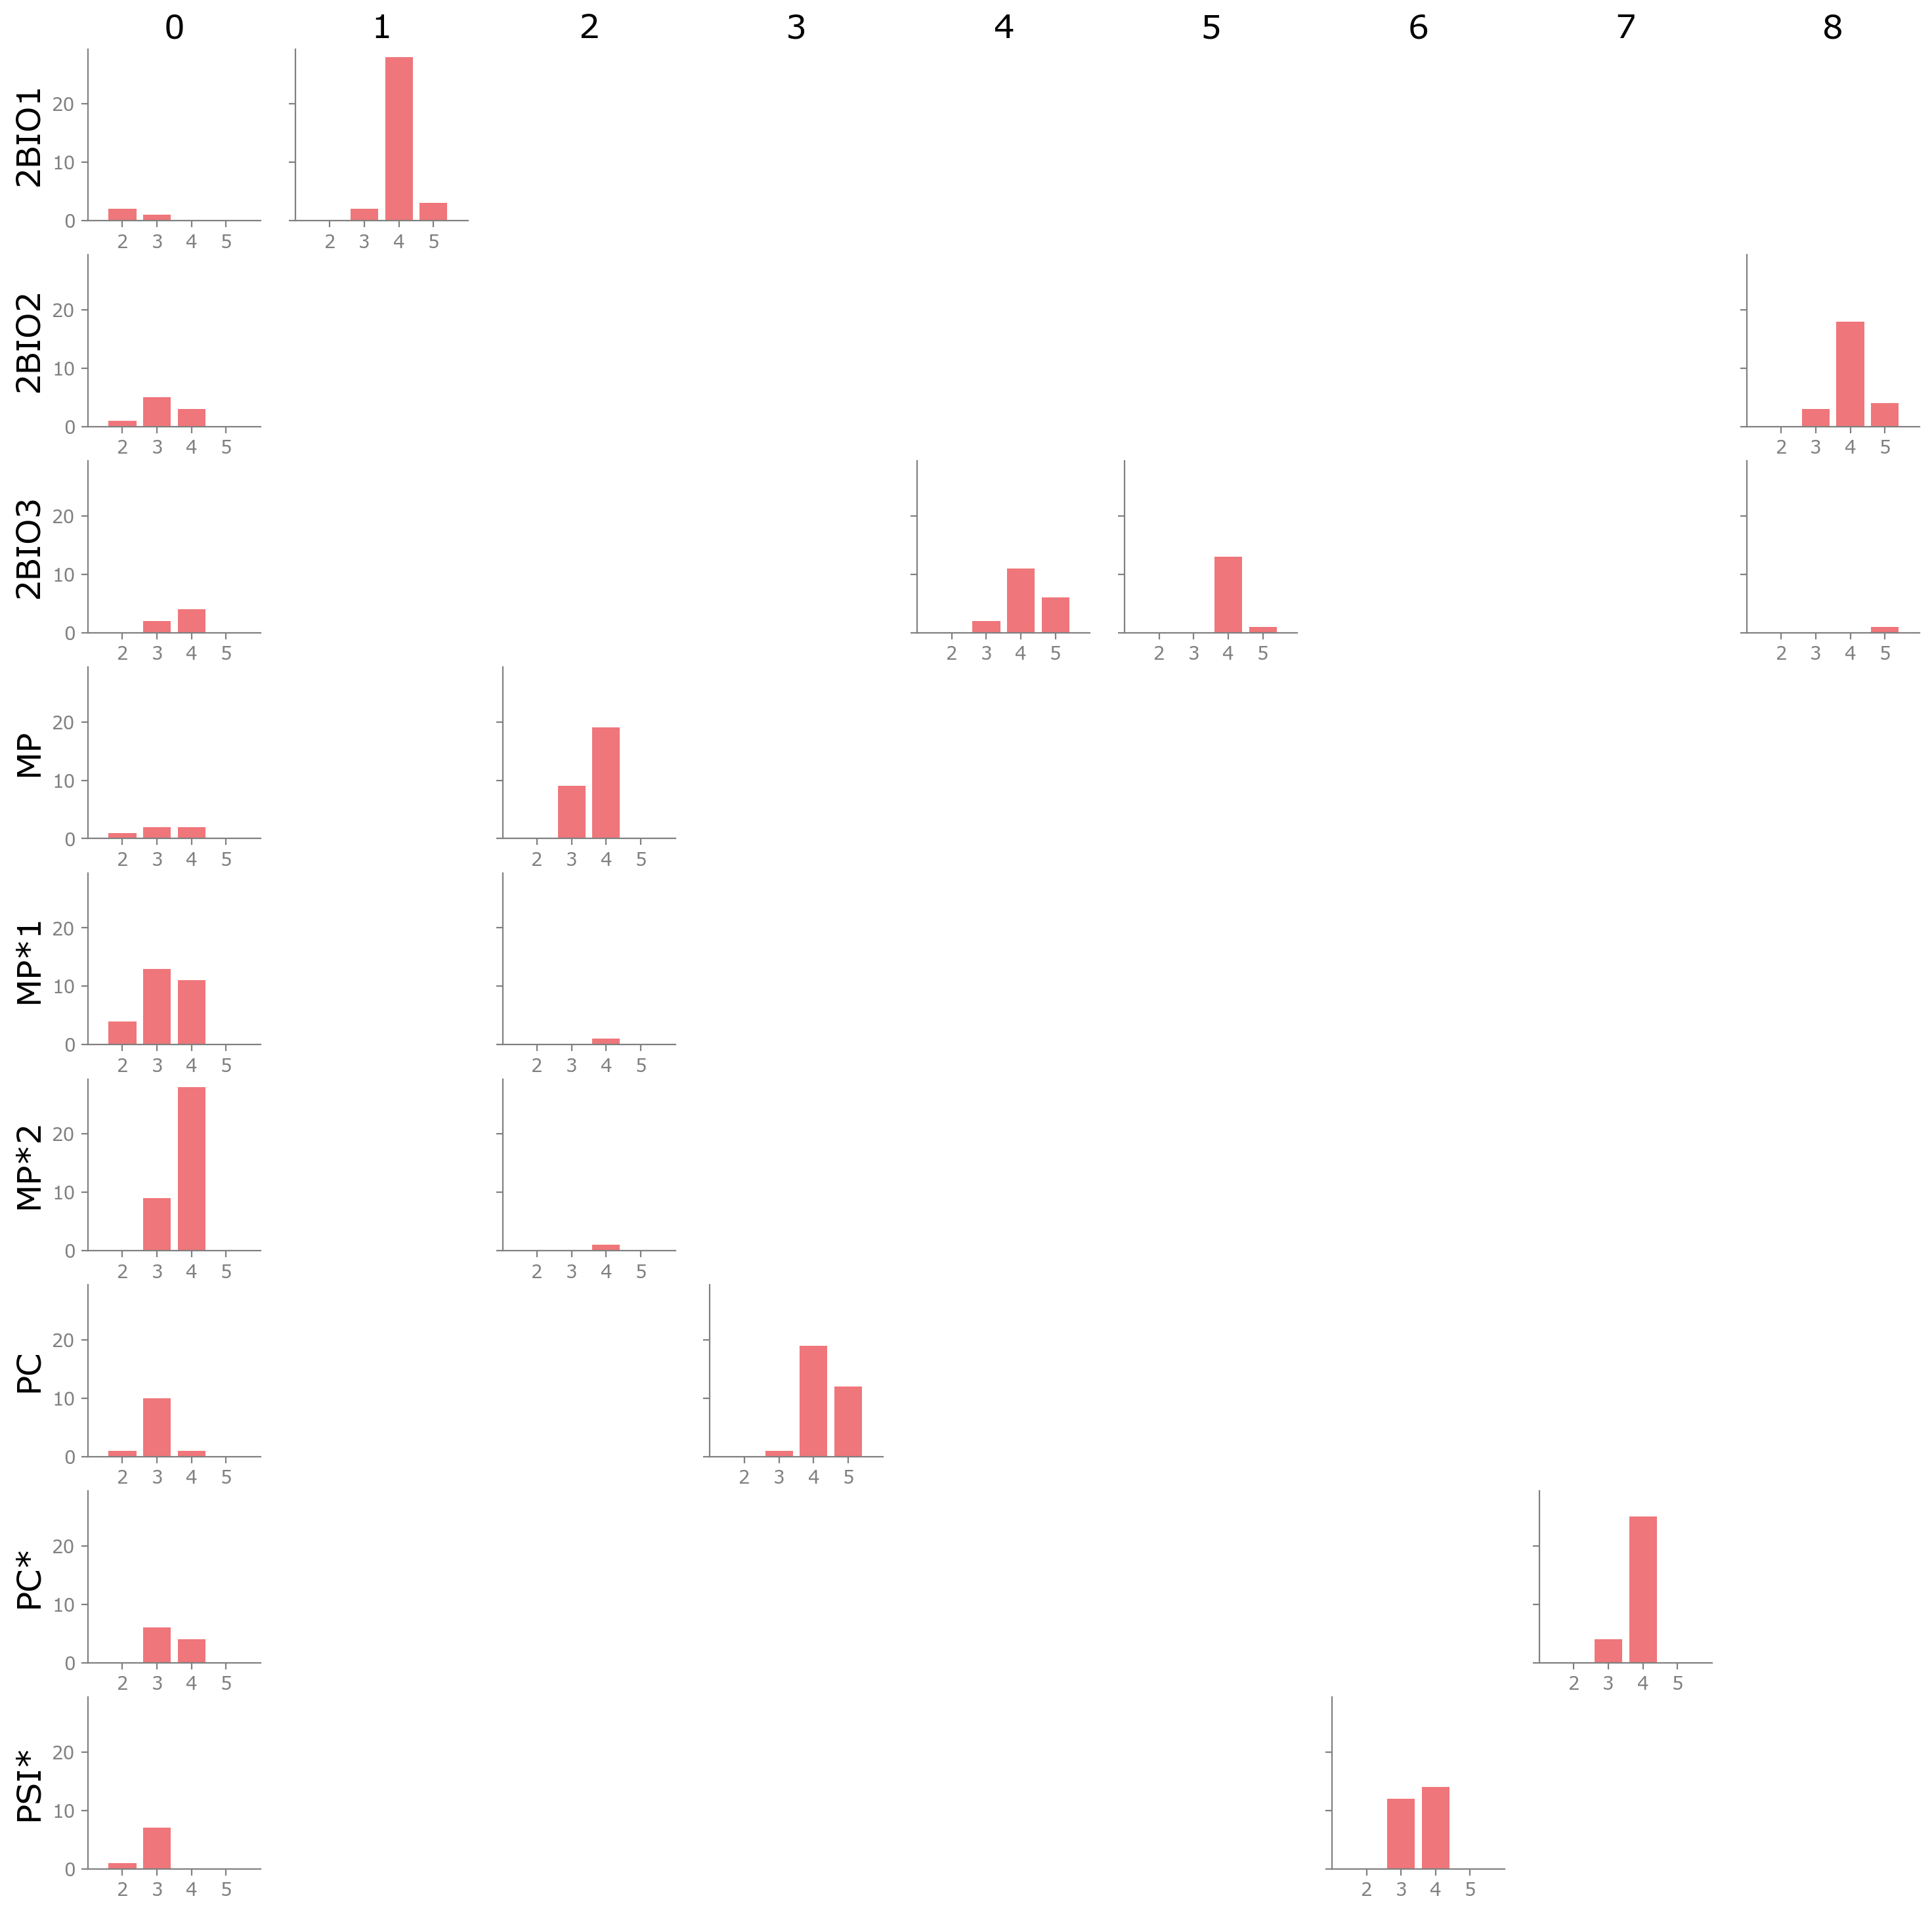

In [16]:
# fullfig = plt.figure(figsize=(18, 18), layout="constrained")
# subfigs = fullfig.subfigures(9, 9, wspace=0.1, hspace=0.1)
fig, axes = plt.subplots(9, 9, sharey=True, figsize=(18, 18))

meta_ls = ["2BIO1", "2BIO2", "2BIO3", "MP", "MP*1", "MP*2", "PC",  "PC*", "PSI*"]
bh_ls = [0, 1, 2, 3, 4, 5, 6, 7, 8]

for i in range(len(meta_ls)):
    for j in range(len(bh_ls)):
        ax = axes[i][j]
        meta_l = meta_ls[i]
        bh_l = bh_ls[j]
        xlabel = "" if i==len(meta_ls)-1 and j==0 else ""
        title = bh_l if i==0 else ""
        ylabel = meta_l if j==0 else ""
        plotMaxOrderDis(meta_l, bh_l, dis=maxOrder_dis, ax=ax, xlabel=xlabel, title=title, ylabel=ylabel)

# plt.subplots_adjust(hspace=0.1)
# plt.tight_layout()
save_path = f"./_Figure/Hyper/HighSchool/" + f"High_school_NodeMaxOrderDis.pdf"
# plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=0.7, right=None, top=None, wspace=None, hspace=0.1)
plt.savefig(save_path, dpi=600)

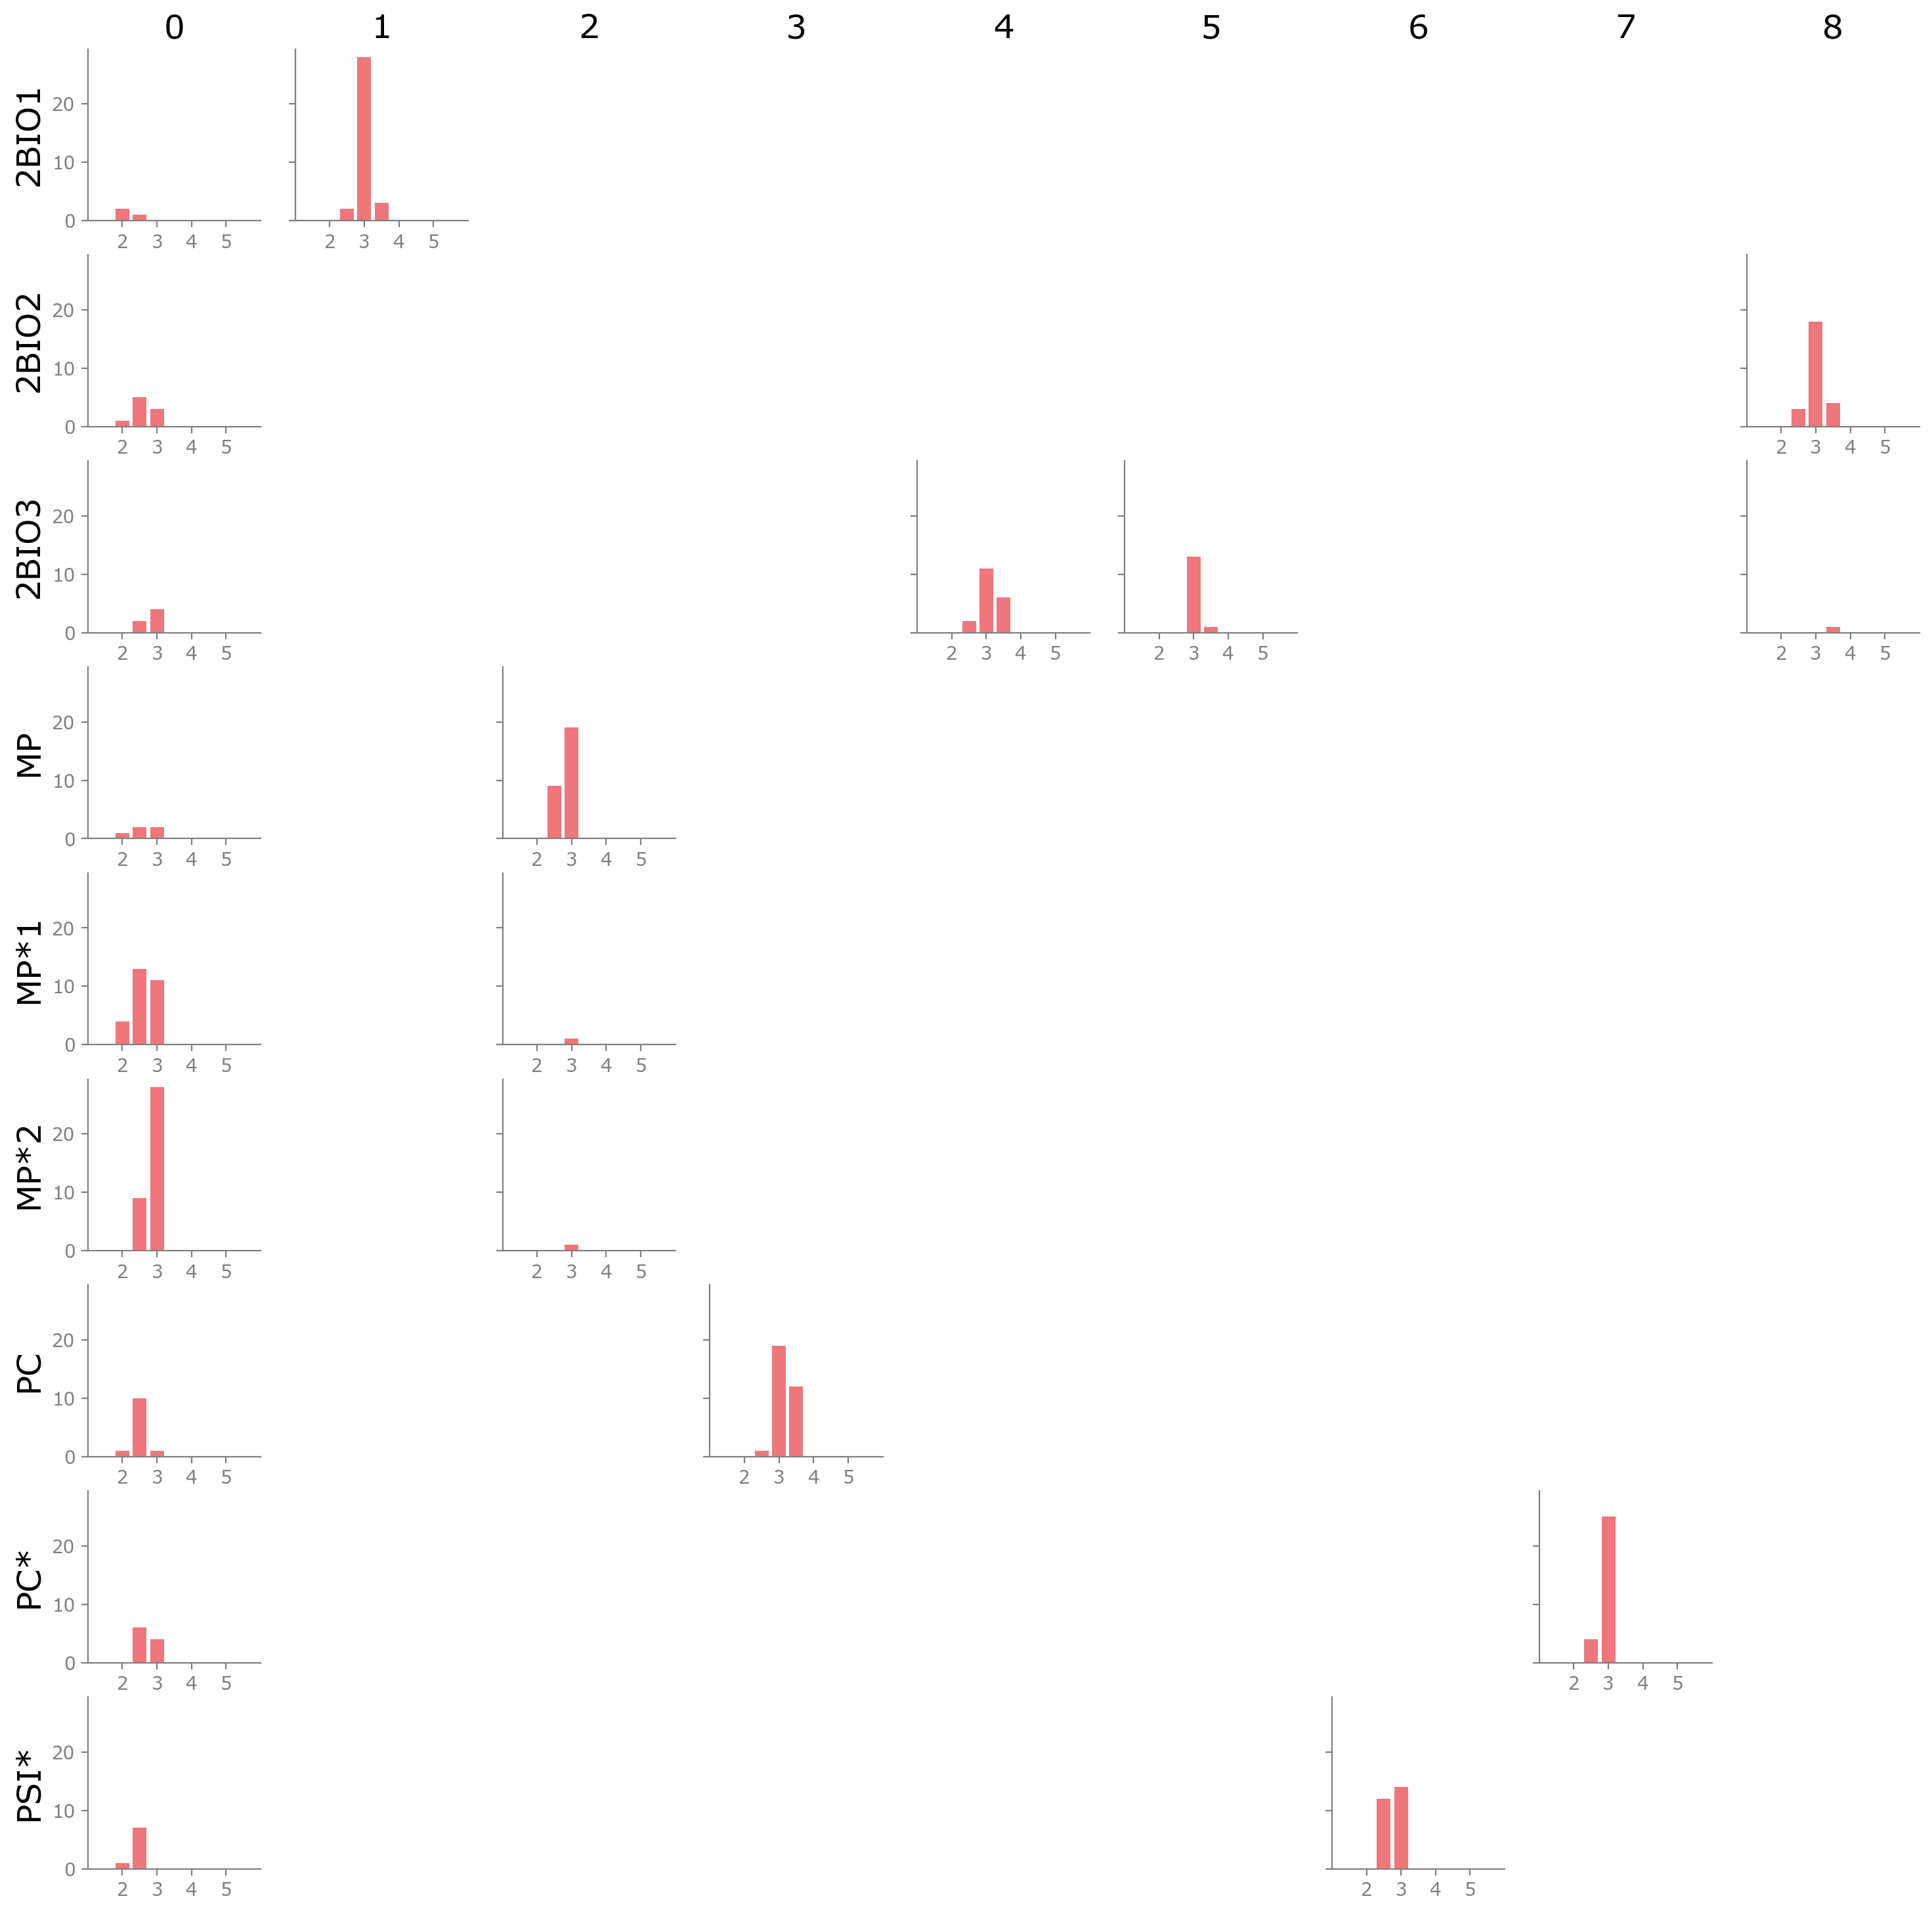

In [17]:
fig, axes = plt.subplots(9, 9, sharey=True, figsize=(18, 18))

meta_ls = ["2BIO1", "2BIO2", "2BIO3", "MP", "MP*1", "MP*2", "PC",  "PC*", "PSI*"]
bh_ls = [0, 1, 2, 3, 4, 5, 6, 7, 8]

for i in range(len(meta_ls)):
    for j in range(len(bh_ls)):    
        ax = axes[i][j]
        meta_l = meta_ls[i]
        bh_l = bh_ls[j]
        xlabel = "" if i==len(meta_ls)-1 and j==0 else ""
        title = bh_l if i==0 else ""
        ylabel = meta_l if j==0 else ""
        plotMaxOrderDis(meta_l, bh_l, dis=meanOrder_dis, ax=ax, xlabel=xlabel, title=title, ylabel=ylabel, width=0.4)

# plt.subplots_adjust(hspace=0.1)
# plt.tight_layout()
save_path = f"./_Figure/Hyper/HighSchool/" + f"High_school_NodeMeanOrderDis.pdf"
# plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=0.7, right=None, top=None, wspace=None, hspace=0.1)
plt.savefig(save_path, dpi=600)

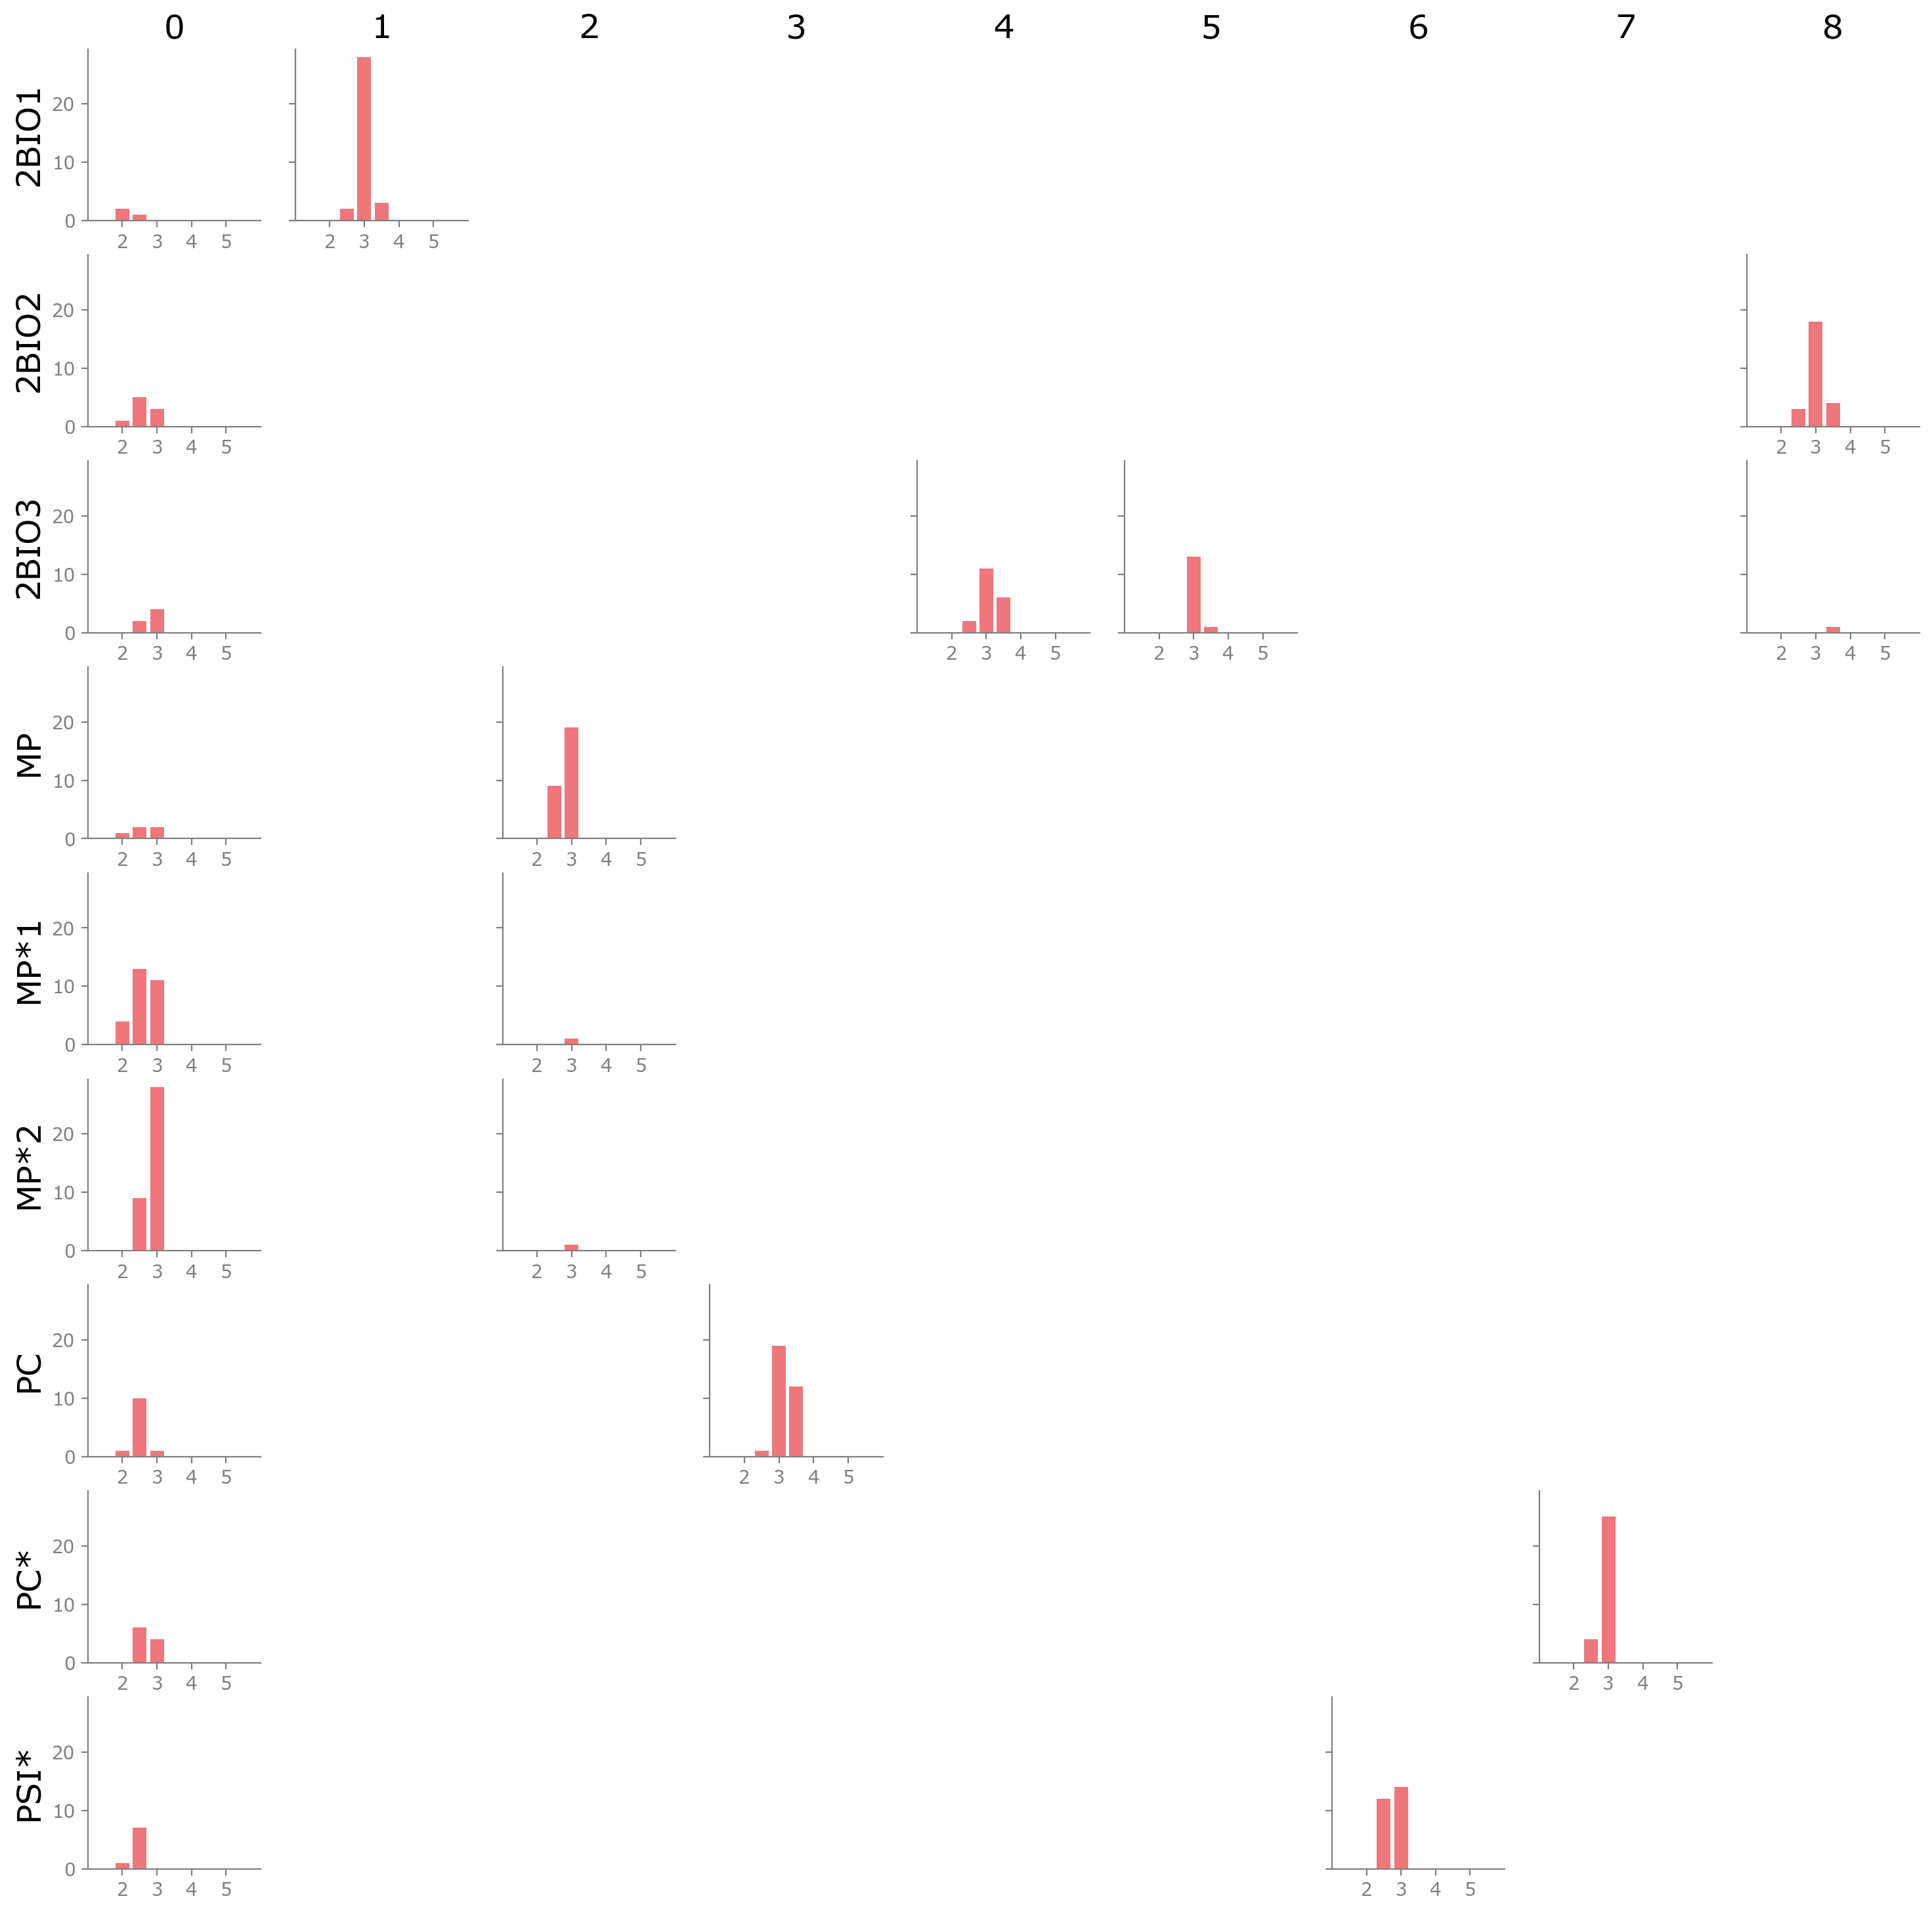

In [18]:
fig, axes = plt.subplots(9, 9, sharey=True, figsize=(18, 18))

meta_ls = ["2BIO1", "2BIO2", "2BIO3", "MP", "MP*1", "MP*2", "PC",  "PC*", "PSI*"]
bh_ls = [0, 1, 2, 3, 4, 5, 6, 7, 8]

for i in range(len(meta_ls)):
    for j in range(len(bh_ls)):    
        ax = axes[i][j]
        meta_l = meta_ls[i]
        bh_l = bh_ls[j]
        xlabel = "" if i==len(meta_ls)-1 and j==0 else ""
        title = bh_l if i==0 else ""
        ylabel = meta_l if j==0 else ""
        plotMaxOrderDis(meta_l, bh_l, dis=medianOrder_dis, ax=ax, xlabel=xlabel, title=title, ylabel=ylabel, width=0.4)

# plt.subplots_adjust(hspace=0.1)
# plt.tight_layout()
save_path = f"./_Figure/Hyper/HighSchool/" + f"High_school_NodeMedianOrderDis.pdf"
plt.savefig(save_path, dpi=600)

[2 3 4 5] [5498 2091  222    7]


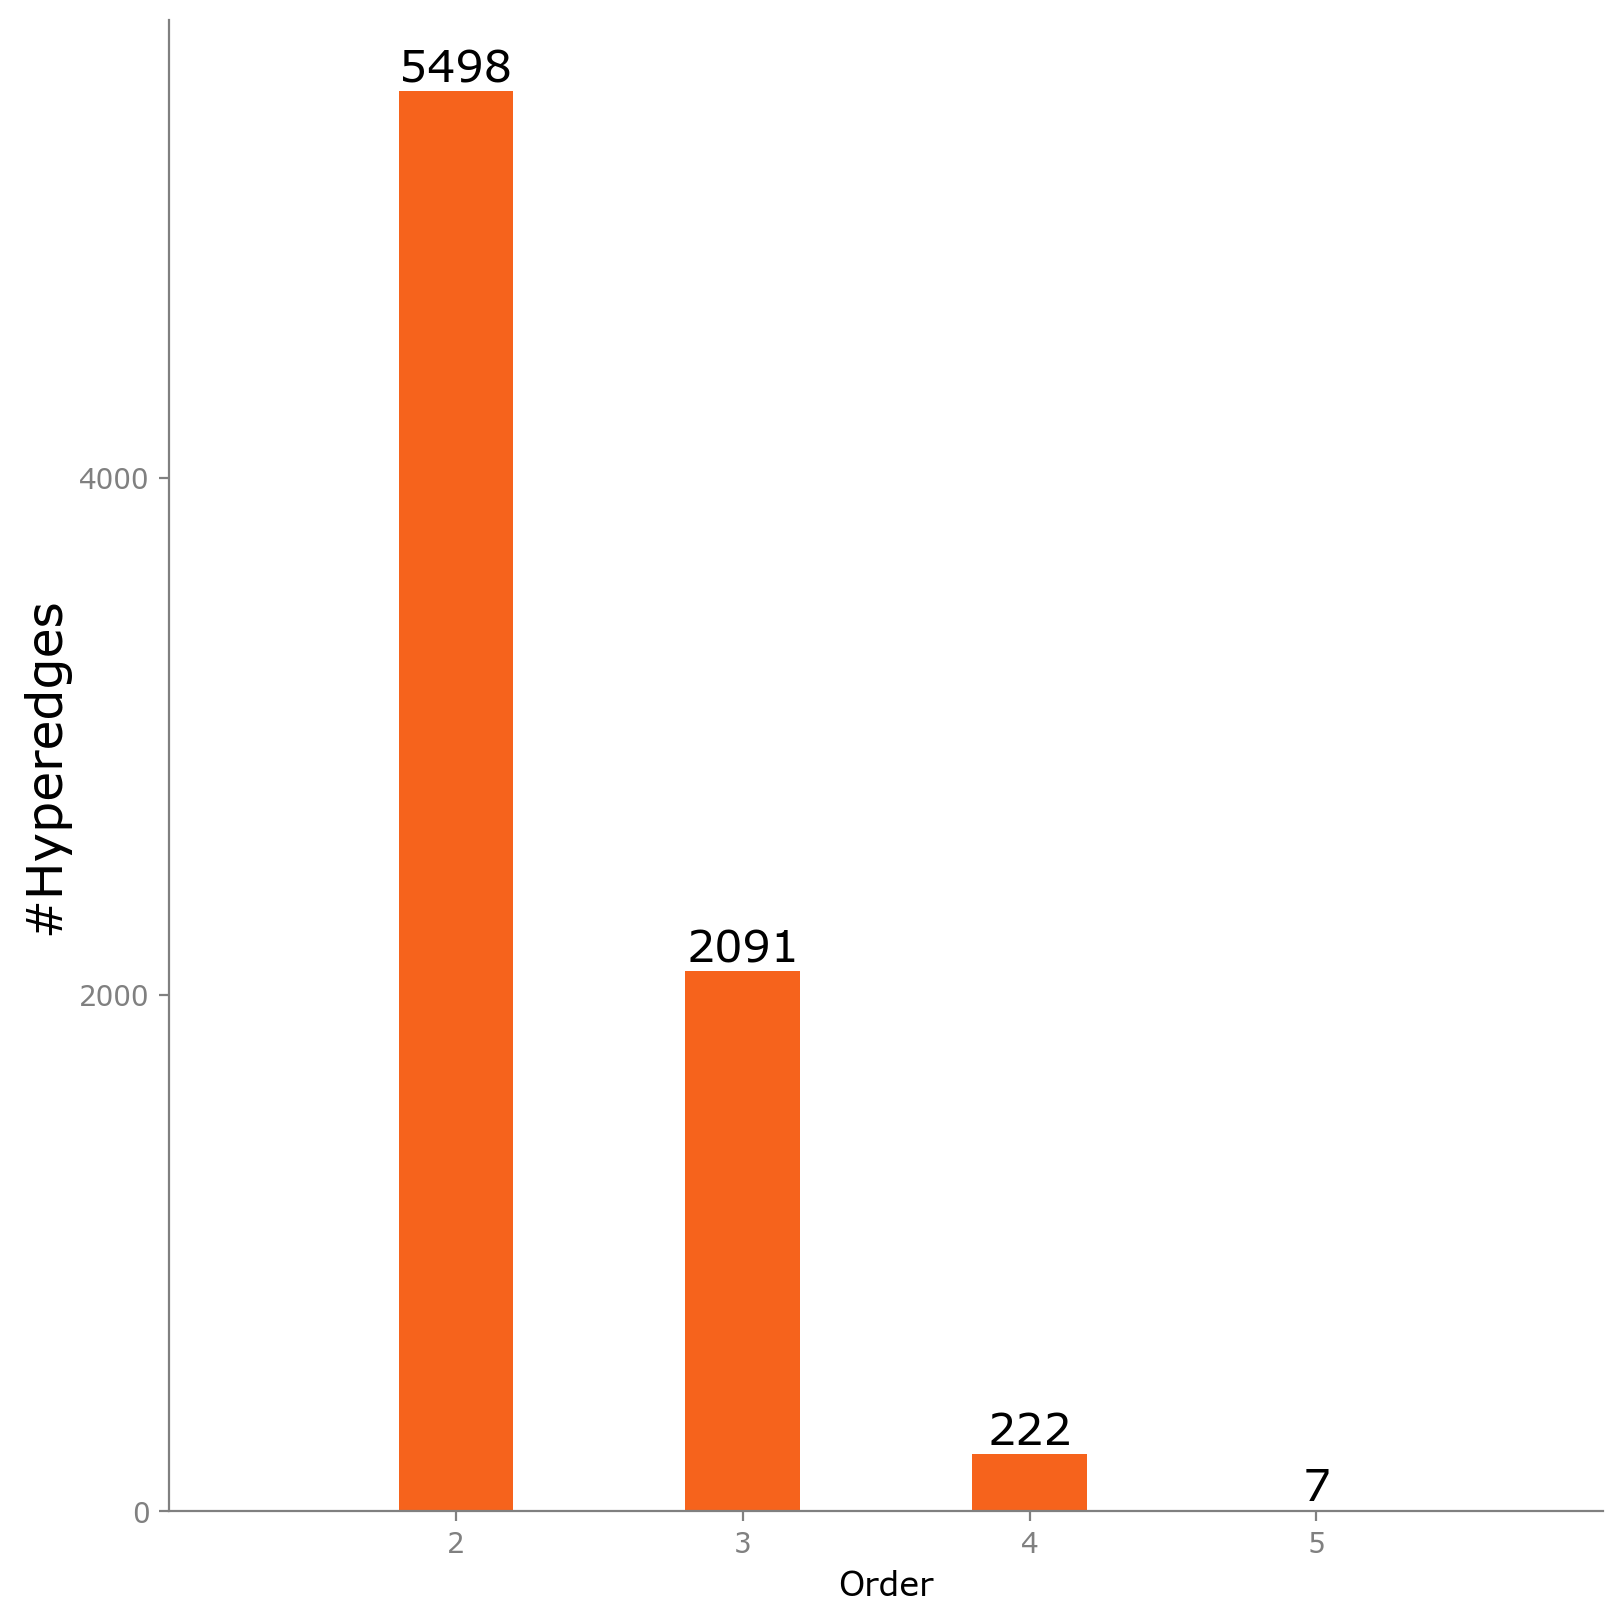

In [48]:
order, edge_order_counts = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
print(order, edge_order_counts)
fullfig = plt.figure(figsize=(8, 8), layout="constrained")
ax = fullfig.subplots()
bars = ax.bar(order, edge_order_counts, color="#F6631C", width=0.4)
ax.set_xticks([2,3,4,5])
# ax.set_ylim(0, 1)
ax.set_xlim(1, 6)
ax.set_xlabel("Order", size=12)
ax.set_ylabel("#Hyperedges", size=18)
ax.yaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=10)
for bar in bars:
    # 获取条形的高度（即数值）
    height = bar.get_height()
    
    # 使用 ax.text() 在条形上方添加文本
    # xy=(x, y) 是文本的坐标
    ax.text(
        bar.get_x() + bar.get_width() / 2, # x 坐标：条形中心的 x 值
        height,                          # y 坐标：条形的高度
        f'{height}',                     # 文本内容，f-string 格式化
        ha='center',                     # 水平对齐：居中
        va='bottom'                      # 垂直对齐：底部（这样文本会显示在条形上方）
    )
save_path = f"./_Figure/Hyper/HighSchool/" + f"High_school_NumberoOfHyperedgesPerOrder.pdf"
plt.savefig(save_path, dpi=600)

# Visual Incidence Matrix

In [55]:
print(meta)

['MP' 'MP' '2BIO3' '2BIO3' 'PC*' 'PC*' '2BIO3' '2BIO3' 'PC' 'PC' 'PC'
 'PC*' 'PC*' '2BIO1' '2BIO1' '2BIO3' '2BIO3' 'PC*' 'PC*' 'PC*' 'MP' 'MP'
 'MP*1' 'MP*1' 'MP' 'MP' 'MP' '2BIO3' '2BIO3' '2BIO2' '2BIO2' '2BIO3'
 '2BIO3' 'PSI*' 'PSI*' '2BIO3' '2BIO3' '2BIO3' 'MP' 'MP' '2BIO3' '2BIO3'
 '2BIO1' 'PC*' 'PC*' 'PC*' '2BIO3' '2BIO3' 'MP*2' 'MP*2' 'MP*1' 'MP*1'
 'MP*2' 'MP*2' '2BIO1' '2BIO1' '2BIO2' '2BIO2' 'MP*2' 'MP*2' '2BIO3'
 'MP*2' 'MP*2' '2BIO3' '2BIO3' '2BIO3' 'MP*1' 'MP*1' 'MP*1' '2BIO3' 'MP'
 'MP*2' 'MP*2' 'MP' 'MP' '2BIO3' '2BIO2' '2BIO2' '2BIO2' 'MP' 'MP' '2BIO1'
 '2BIO1' '2BIO2' '2BIO3' '2BIO3' '2BIO1' '2BIO1' 'PC*' 'PC*' '2BIO3'
 '2BIO3' 'MP' '2BIO3' 'MP*1' 'MP*1' '2BIO3' 'MP*2' 'MP*2' 'MP*2' '2BIO3'
 'MP' 'MP' 'PC*' 'PC*' 'PC*' '2BIO3' '2BIO3' 'MP' '2BIO1' '2BIO1' 'PC*'
 'PC*' '2BIO3' '2BIO3' '2BIO3' '2BIO3' 'MP*2' 'MP*1' 'MP*1' '2BIO3'
 '2BIO1' '2BIO1' '2BIO1' 'MP*2' 'MP*2' '2BIO3' 'MP' '2BIO3' '2BIO3' 'MP'
 '2BIO2' 'PC' 'PC*' '2BIO1' 'PC' 'PC' '2BIO2' '2BIO2' 'PC' 'PC' 'PC' 'M

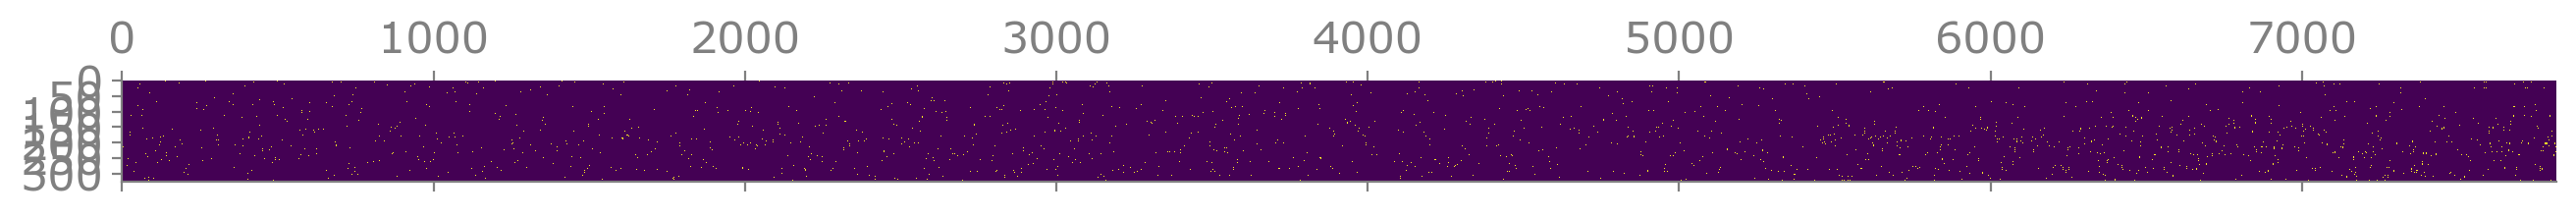

In [62]:
H = ehg.H.toarray()
orders = np.sum(H, axis=0)
sorted_col_index = np.argsort(orders)
H = H[:, sorted_col_index]
sorted_row_index = np.argsort(BHpartition)  # Sort row(nodes) by bh communuities
H = H[sorted_row_index, :]
df_named = pd.DataFrame(H, columns=orders[sorted_col_index], index=BHpartition[sorted_row_index])
plt.matshow(H)
df_named.to_excel(f"./_Figure/Hyper/HighSchool/H_rowByBHcommunities_colByOrder.xlsx")

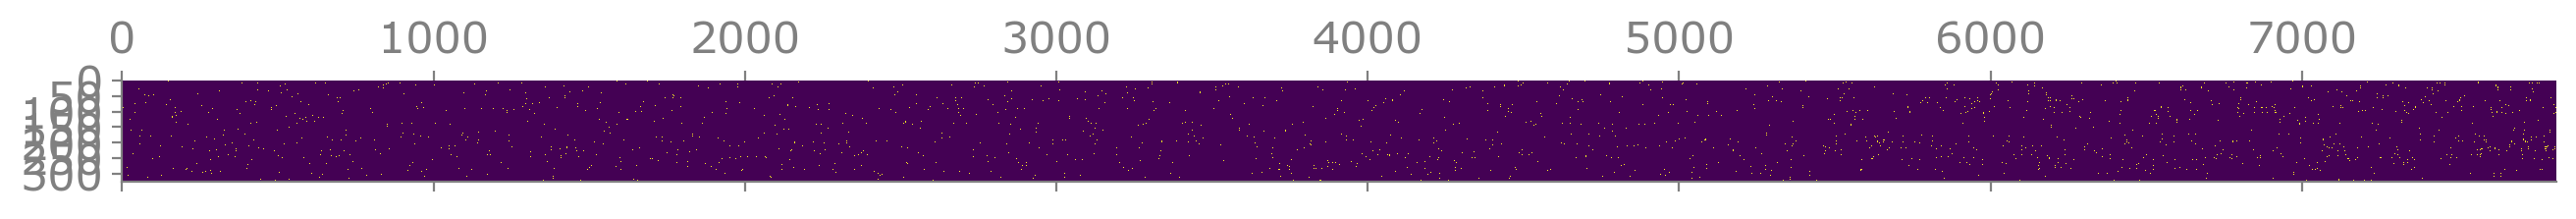

In [63]:
H = ehg.H.toarray()
orders = np.sum(H, axis=0)
sorted_col_index = np.argsort(orders)
H = H[:, sorted_col_index]
meta_ls = ["2BIO1", "2BIO2", "2BIO3", "MP", "MP*1", "MP*2", "PC",  "PC*", "PSI*"]
priority_map = {name: i for i, name in enumerate(meta_ls)}
vectorized_map = np.vectorize(priority_map.get)
priority_array = vectorized_map(meta)
sorted_row_index = np.argsort(priority_array) # Sort row(nodes) by class
H = H[sorted_row_index, :]
df_named = pd.DataFrame(H, columns=orders[sorted_col_index], index=meta[sorted_row_index])
plt.matshow(H)
df_named.to_excel(f"./_Figure/Hyper/HighSchool/H_rowByClass_colByOrder.xlsx")

# Observation abnormal nodes

In [39]:
def related_subgraph(seed_nodes, H, partition, meta, save_path=None):
    related_hyperedges = np.nonzero(H[seed_nodes, :].sum(axis=0).flatten())[0]
    related_nodes = np.nonzero(H[:, related_hyperedges].sum(axis=1).flatten())[0]
    related_subhypergraph_H = H[:, related_hyperedges][related_nodes, :]
    # Sort col by order
    orders = np.sum(related_subhypergraph_H.toarray(), axis=0)
    sorted_col_index = np.argsort(orders)
    related_subhypergraph_H = related_subhypergraph_H[:, sorted_col_index]
    # Without aggregate
    # row_names = [f"{i}_{meta[i]}_{BHpartition[i]}"for i in related_nodes]
    # df_named = pd.DataFrame(related_subhypergraph_H.toarray(), columns=orders[sorted_col_index], index=row_names)
    # Aggregate rows
    row_names = [f"{meta[i]}_{BHpartition[i]}"for i in related_nodes]
    sorted_unique_rownames = sorted(list(set(row_names)))
    aggregate_row_H = np.zeros((len(sorted_unique_rownames), np.size(sorted_col_index)))
    for i, name in enumerate(sorted_unique_rownames):
        temp_row_indices = np.where(np.array(row_names)==name)[0]
        temp_aggregate_row = related_subhypergraph_H[temp_row_indices, :].sum(axis=0)
        aggregate_row_H[i, :] = temp_aggregate_row
    sorted_unique_class = [name.split("_")[0] for name in sorted_unique_rownames]
    sorted_unique_community = [name.split("_")[1] for name in sorted_unique_rownames]
    row_names = pd.MultiIndex.from_arrays([sorted_unique_class, sorted_unique_community], names=['Class', 'Community'])
    # df_named = pd.DataFrame(aggregate_row_H, columns=orders[sorted_col_index], index=sorted_unique_rownames)
    # Aggregate cols
    col_orders = orders[sorted_col_index]
    sorted_unique_colorders = sorted(list(set(col_orders)))
    aggregate_col_H = np.zeros((len(sorted_unique_rownames), len(sorted_unique_colorders)))
    for i, o in enumerate(sorted_unique_colorders):
        temp_col_indices = np.where(np.array(col_orders)==o)[0]
        temp_aggregate_col = aggregate_row_H[:, temp_col_indices].sum(axis=1) # / np.size(temp_col_indices)  # Normalized by number of order o hyperedges
        aggregate_col_H[:, i] = temp_aggregate_col
    # print(np.shape(related_subhypergraph_H), np.shape(orders[sorted_col_index]), np.shape(row_names))
    df_named = pd.DataFrame(aggregate_col_H, columns=[f"Order {o}" for o in sorted_unique_colorders], index=row_names)
    
    # plt.matshow(related_subhypergraph_H.toarray())
    if save_path is not None:
        df_named.to_excel(save_path)

In [24]:
abnormal_nodes_1 = set(np.where(meta=="MP*1")[0]) & set(np.where(BHpartition==2)[0])
abnormal_nodes_2 = set(np.where(meta=="MP*2")[0]) & set(np.where(BHpartition==2)[0])
print(abnormal_nodes_1, abnormal_nodes_2)

{168} {71}


In [40]:
adnormal_nodes = list(abnormal_nodes_1)
# save_path = f"./_Figure/Hyper/HighSchool/RelatedAggregateH_{adnormal_nodes[0]}_{meta[adnormal_nodes[0]].replace('*', '')}_{BHpartition[adnormal_nodes[0]]}.xlsx"
save_path = f"./_Figure/Hyper/HighSchool/RelatedAggregateRowColH_{adnormal_nodes[0]}_{meta[adnormal_nodes[0]].replace('*', '')}_{BHpartition[adnormal_nodes[0]]}.xlsx"
related_subgraph(seed_nodes=adnormal_nodes, H=ehg.H, partition=BHpartition, meta=meta, save_path=save_path)

In [41]:
adnormal_nodes = list(abnormal_nodes_2)
save_path = f"./_Figure/Hyper/HighSchool/RelatedAggregateRowColH_{adnormal_nodes[0]}_{meta[adnormal_nodes[0]].replace('*', '')}_{BHpartition[adnormal_nodes[0]]}.xlsx"
related_subgraph(seed_nodes=adnormal_nodes, H=ehg.H, partition=BHpartition, meta=meta, save_path=save_path)

In [42]:
normal_nodes = set(np.where(meta=="MP")[0]) & set(np.where(BHpartition==2)[0])
print(normal_nodes)

{0, 1, 130, 270, 20, 21, 148, 150, 24, 25, 154, 26, 278, 152, 151, 166, 317, 320, 322, 70, 73, 74, 79, 80, 101, 102, 108, 127}


In [45]:
normal_nodes = [0]
save_path = f"./_Figure/Hyper/HighSchool/RelatedAggregateRowColH_{normal_nodes[0]}_{meta[normal_nodes[0]].replace('*', '')}_{BHpartition[normal_nodes[0]]}.xlsx"
related_subgraph(seed_nodes=normal_nodes, H=ehg.H, partition=BHpartition, meta=meta, save_path=save_path)

[126]


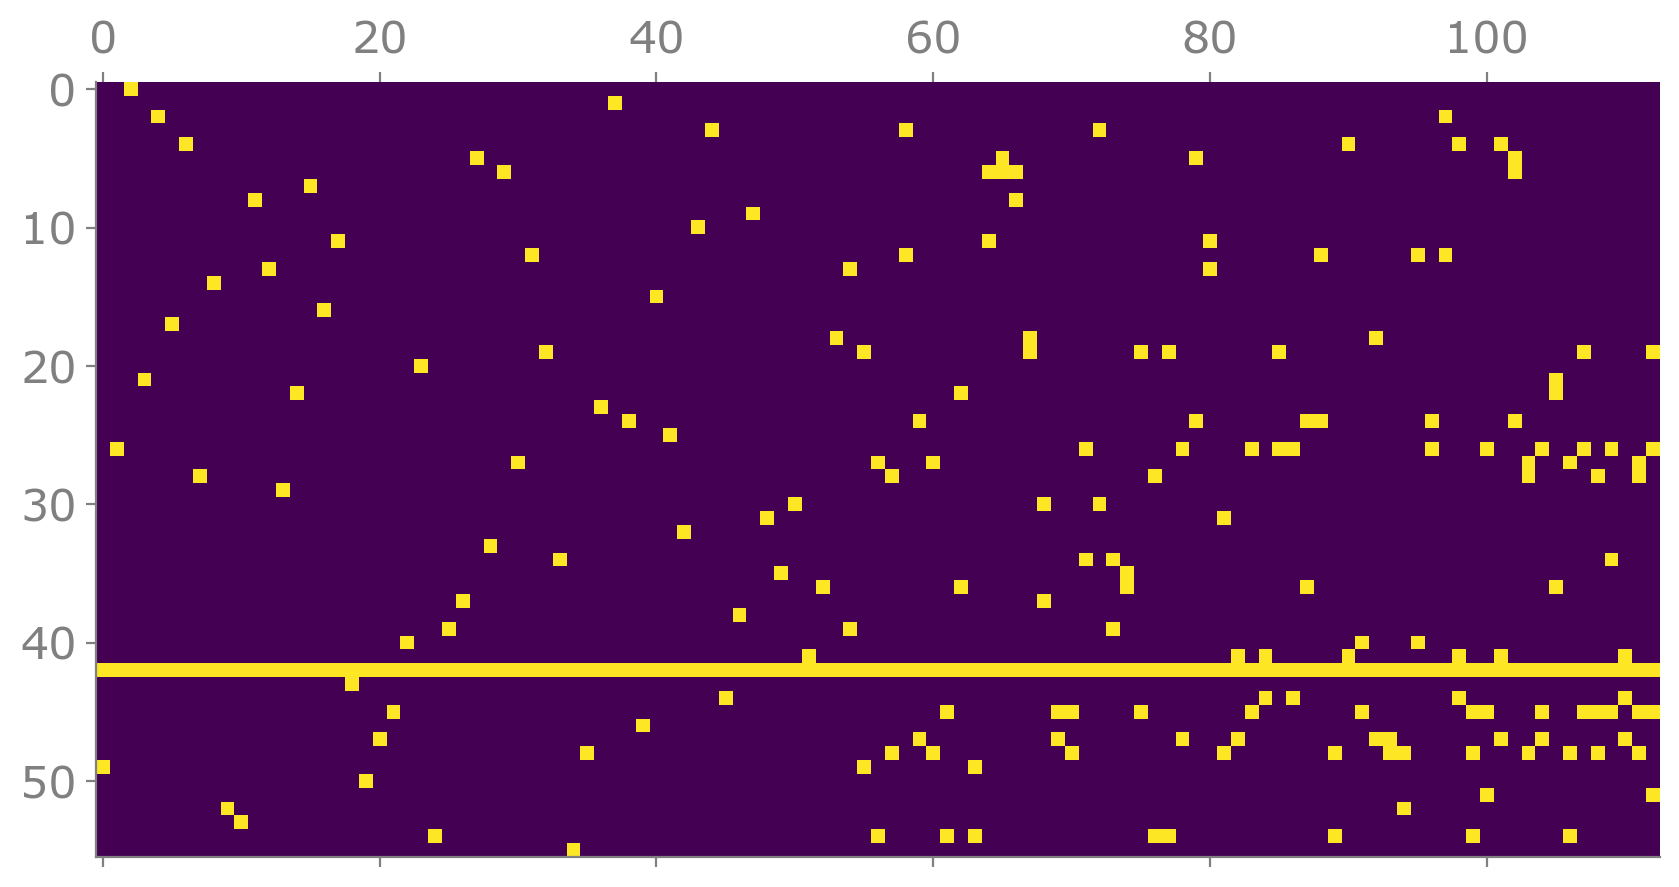

In [32]:
adnormal_nodes = list(set(np.where(meta=="2BIO3")[0]) & set(np.where(BHpartition==8)[0]))
print(adnormal_nodes)
save_path = f"./_Figure/Hyper/HighSchool/RelatedAggregateRowH_{adnormal_nodes[0]}_{meta[adnormal_nodes[0]].replace('*', '')}_{BHpartition[adnormal_nodes[0]]}.xlsx"
related_subgraph(seed_nodes=abnormal_nodes, H=ehg.H, partition=BHpartition, meta=meta, save_path=save_path)

[128, 35, 36, 69, 37, 85]
(56, 113) (113,) (56,)


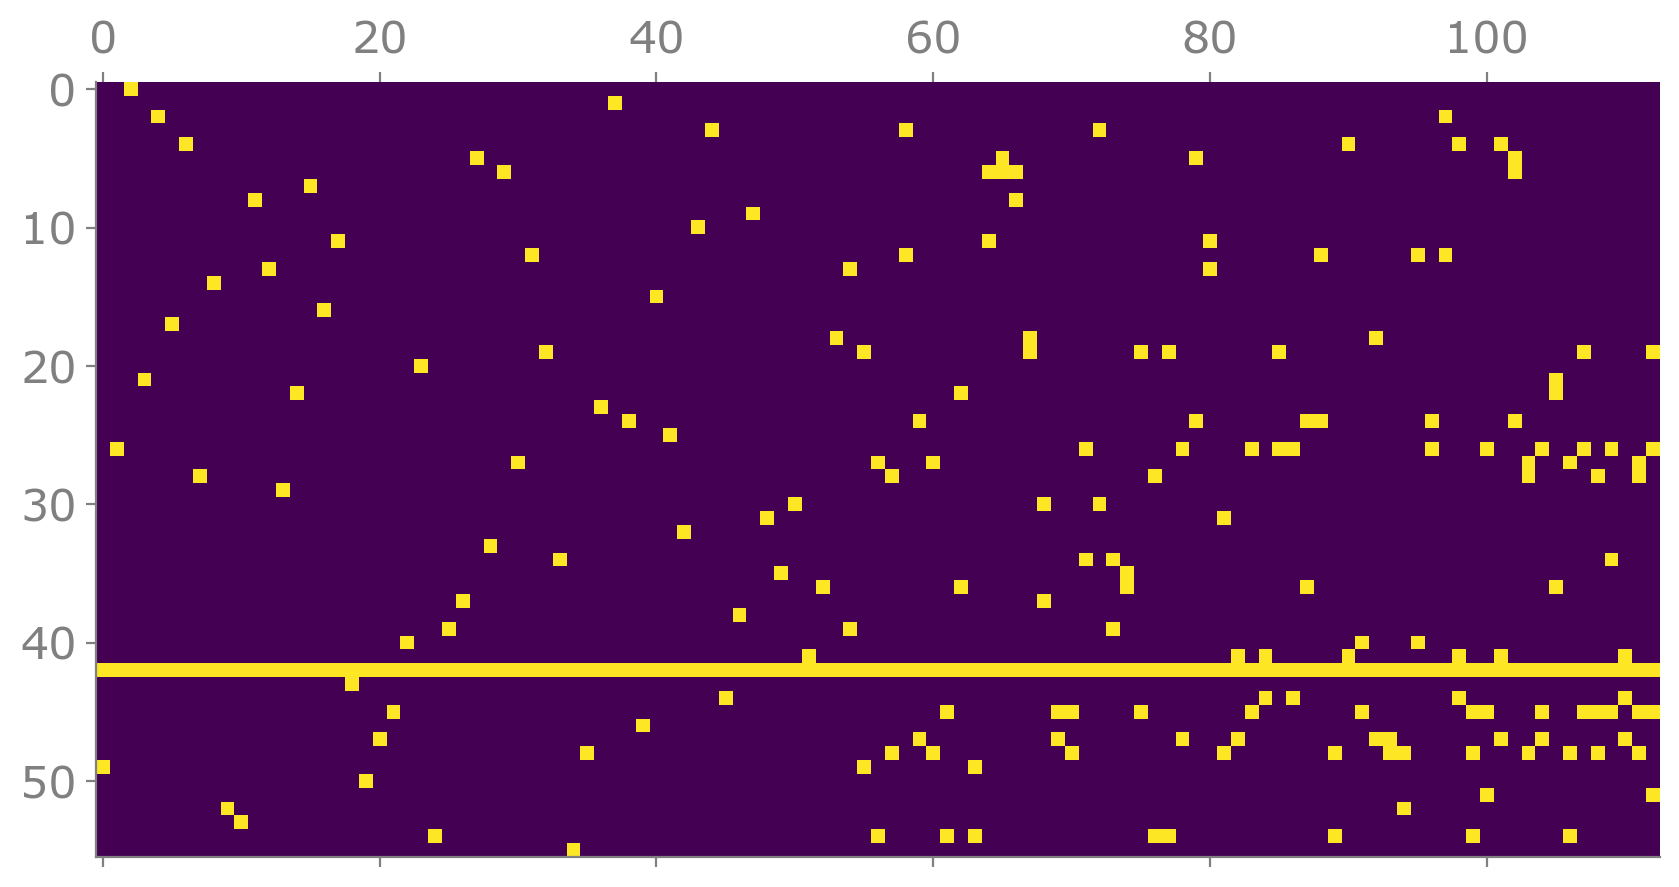

In [11]:
adnormal_nodes = list(set(np.where(meta=="2BIO3")[0]) & set(np.where(BHpartition==0)[0]))
print(adnormal_nodes)
save_path = f"./_Figure/Hyper/HighSchool/RelatedH_{len(adnormal_nodes)}nodesIn_{meta[adnormal_nodes[0]].replace('*', '')}_{BHpartition[adnormal_nodes[0]]}.xlsx"
related_subgraph(seed_nodes=abnormal_nodes, H=ehg.H, partition=BHpartition, meta=meta, save_path=save_path)

# Distribution of Hedge

In [4]:
def getDistributedHedgeinPartition(H, partition, key_by=None):
    recorded = dict()
    for ei in range(np.shape(H)[1]):
        order = np.sum(H[:, ei])
        hedge = np.where(H[:, ei]==1)[0]
        hedge_community = sorted([partition[i] for i in hedge])
        if key_by is None:
            hedge_community = " ".join([str(c) for c in sorted(hedge_community)])
            key = hedge_community
        elif key_by == "#unique":
            key = f"Order {order} #uniqueLabel {np.size(np.unique(np.array(hedge_community)))}"
        if key not in recorded.keys():
            recorded[key] = 1
        else:
            recorded[key] += 1
    return recorded

In [5]:
DisHedgeByMeta = getDistributedHedgeinPartition(ehg.H.toarray(), meta)
DisHedgeByBH = getDistributedHedgeinPartition(ehg.H.toarray(), BHpartition)

In [50]:
num_unique_comb = 0
for meta_comb in DisHedgeByMeta.keys():
    metas =  meta_comb.split(" ")
    if len(metas) == 4:
        print(f"{meta_comb} {DisHedgeByMeta[meta_comb]}")
        num_unique_comb += 1
print(f"Total {num_unique_comb} combinations of 4 order hyperedges by Class")

2BIO3 2BIO3 2BIO3 2BIO3 38
PC* PC* PC* PC* 18
PC PSI* PSI* PSI* 2
MP*2 MP*2 MP*2 MP*2 13
2BIO1 2BIO1 2BIO1 2BIO1 21
2BIO1 2BIO1 2BIO1 2BIO3 2
PC PC PC PC 43
PSI* PSI* PSI* PSI* 5
MP MP MP*2 MP*2 1
MP MP*1 MP*2 MP*2 1
2BIO2 2BIO2 2BIO2 2BIO2 13
MP MP MP MP 10
2BIO1 2BIO1 2BIO3 2BIO3 3
2BIO2 2BIO2 2BIO3 2BIO3 3
MP MP*1 MP*1 MP*1 1
2BIO1 PC PC* PC* 1
MP MP MP MP*2 6
MP MP*1 MP*1 MP*2 1
MP*1 MP*2 MP*2 MP*2 2
2BIO1 2BIO1 2BIO2 2BIO3 3
2BIO3 2BIO3 MP*2 MP*2 1
2BIO1 2BIO2 2BIO2 2BIO3 4
PC PC* PSI* PSI* 1
2BIO1 2BIO1 2BIO2 2BIO2 3
MP MP*2 PC PC 1
MP MP MP MP*1 1
2BIO1 2BIO1 2BIO1 2BIO2 5
PC PC PC PC* 3
2BIO2 2BIO3 2BIO3 PC* 1
2BIO1 2BIO2 2BIO2 2BIO2 2
MP*1 MP*1 MP*2 MP*2 3
MP*1 MP*1 MP*1 MP*1 2
2BIO2 2BIO2 2BIO2 2BIO3 6
MP MP MP*2 PSI* 1
2BIO1 2BIO1 2BIO3 MP 1
Total 35 combinations of 4 order hyperedges by Class


In [52]:
num_unique_comb = 0
for community_comb in DisHedgeByBH.keys():
    communities =  community_comb.split(" ")
    if len(communities) == 4:
        print(f"{community_comb} {DisHedgeByBH[community_comb]}")
        num_unique_comb += 1
print(f"Total {num_unique_comb} combinations of 4 order hyperedges by Communities")

4 4 4 4 15
0 7 7 7 3
3 6 6 6 2
0 0 0 0 21
1 1 1 1 21
5 5 5 5 7
1 1 1 8 6
3 3 3 3 42
6 6 6 6 5
0 2 2 2 5
0 0 0 2 2
8 8 8 8 15
2 2 2 2 13
4 5 5 5 4
7 7 7 7 15
0 0 1 1 1
4 8 8 8 2
1 3 7 7 1
5 5 5 8 1
1 1 8 8 6
0 0 4 4 1
1 8 8 8 5
0 3 6 6 1
0 5 5 5 2
0 2 3 3 1
4 5 8 8 1
0 5 5 8 1
1 1 5 5 1
4 4 4 5 3
0 0 8 8 1
3 3 3 7 3
5 5 8 8 1
4 4 7 8 1
4 4 5 5 3
1 1 4 4 1
0 3 3 3 1
0 4 5 5 1
5 8 8 8 1
2 2 2 6 1
1 4 8 8 1
0 0 0 5 1
1 1 1 5 1
0 0 5 5 1
1 1 2 4 1
Total 44 combinations of 4 order hyperedges by Communities


In [6]:
np.unique(np.array(["a", "a", "a", "b"]), return_counts=True)

(array(['a', 'b'], dtype='<U1'), array([3, 1], dtype=int64))

In [14]:
def getGroupBarResultDF(disHedge):
    result = dict()
    for key in disHedge.keys():
        order = len(key.split(" "))
        # number_unique_label = len(set(key.split(" ")))
        _, label_count = np.unique(np.array(key.split(" ")), return_counts=True)
        max_samelabel_count = np.max(label_count)
        if order not in result.keys():
            result[order] = dict()
        if max_samelabel_count not in result[order].keys():
            result[order][max_samelabel_count] = disHedge[key]
        else:
            result[order][max_samelabel_count] += disHedge[key]
    result = {k: result[k] for k in sorted(result.keys())}
    for k in result.keys():
        result[k] = {c: result[k][c] for c in sorted(result[k].keys())}
    df = pd.DataFrame.from_dict(result, orient='index')
    return df

In [8]:
def addTextOnBar(ax):
    for bar in ax.patches:
        # bar.get_height() 获取条形的高度（即数值）
        height = bar.get_height()
        # ax.text() 在条形上方添加文本
        ax.text(
            bar.get_x() + bar.get_width() / 2, # x坐标: 条形中心的x值
            height,                          # y坐标: 条形的高度
            f'{int(height)}',                     # 文本内容，使用f-string格式化
            ha='center',                     # 水平对齐: 居中
            va='bottom',                     # 垂直对齐: 底部，这样文本会显示在条形上方
            fontsize=10
        )

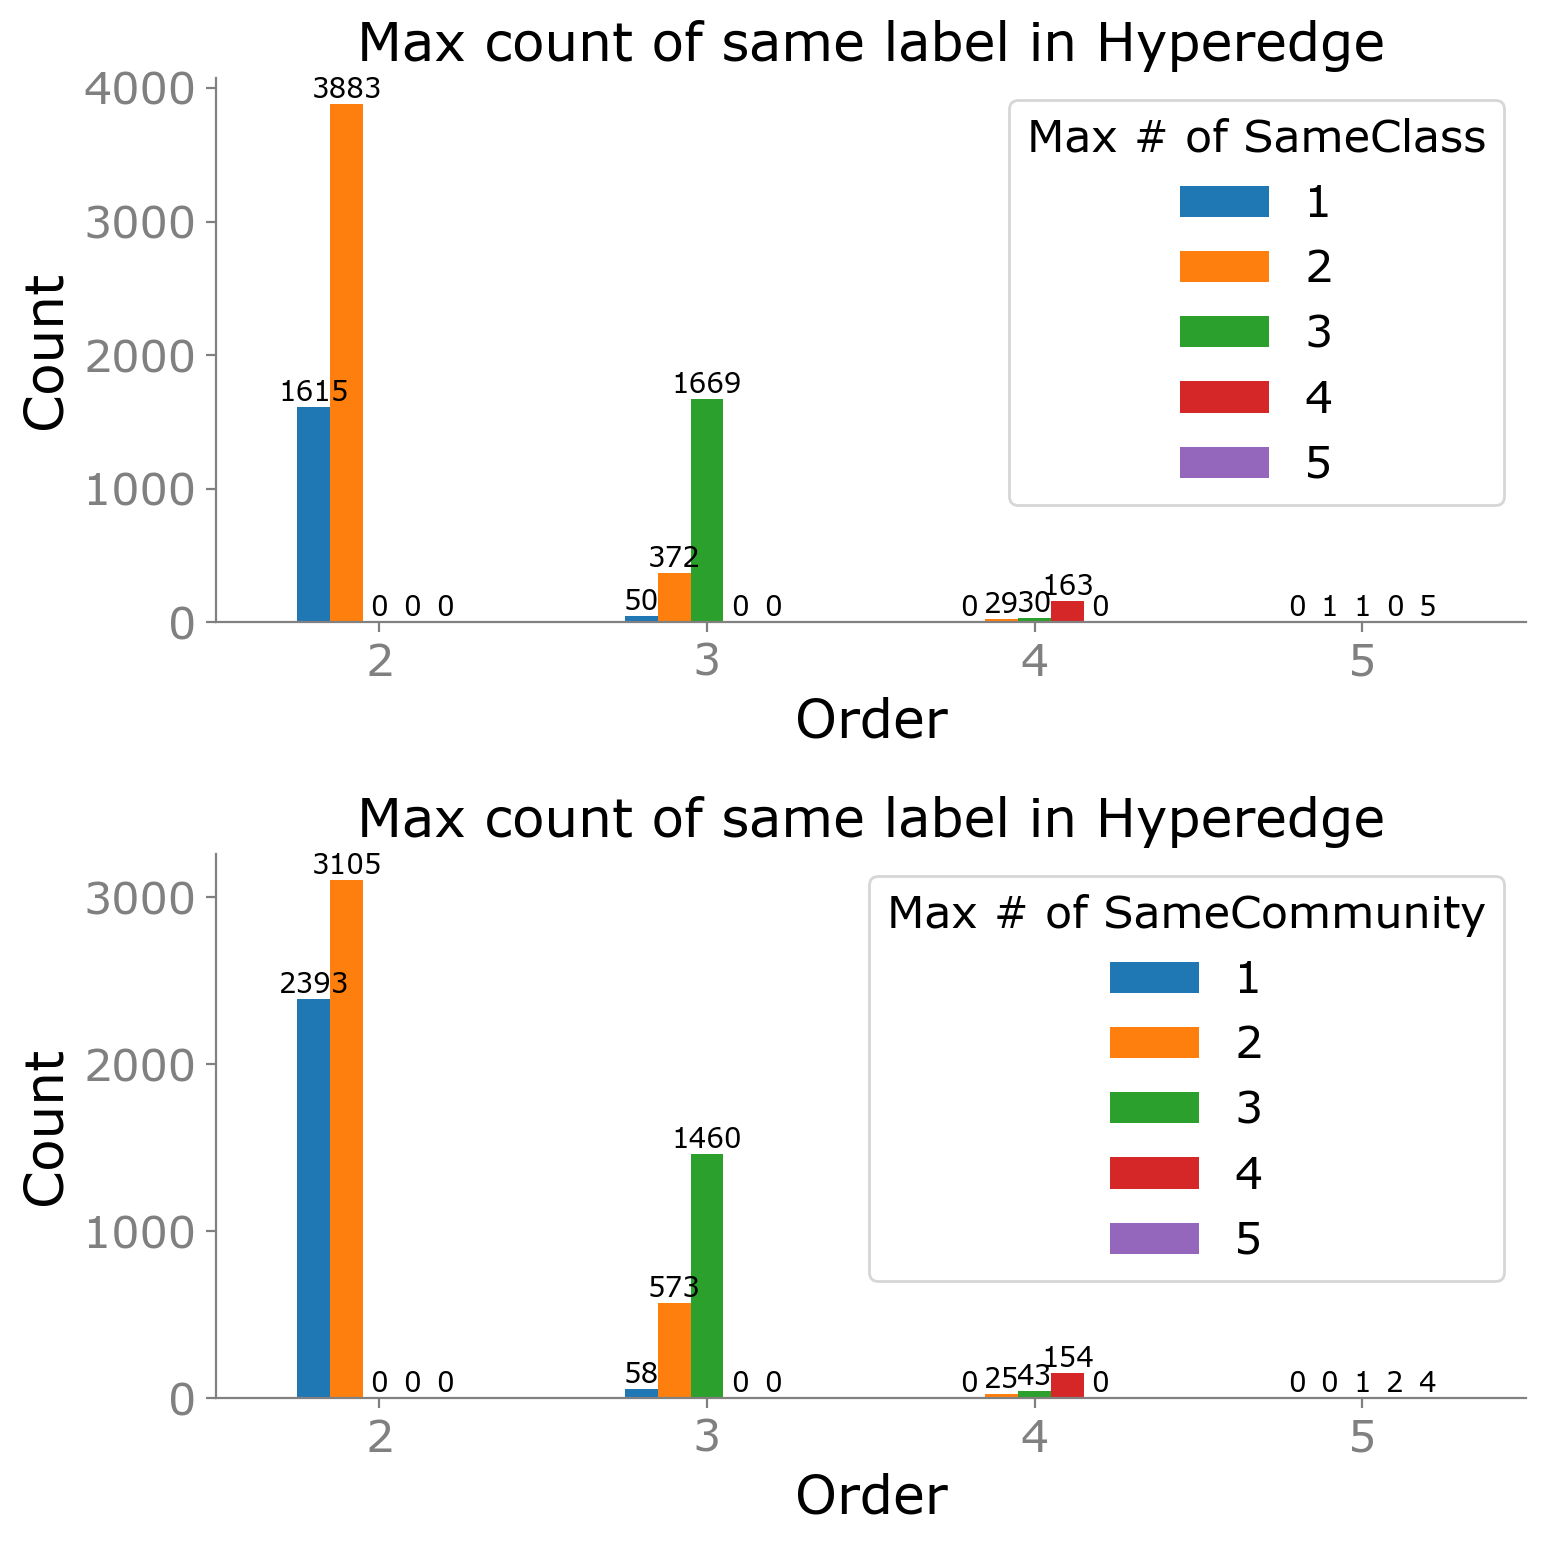

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

df = getGroupBarResultDF(DisHedgeByMeta)
df.plot.bar(ax=axes[0], rot=0)
# 设置图表标题和标签
axes[0].set_title('Max count of same label in Hyperedge')
axes[0].set_xlabel('Order')
axes[0].set_ylabel('Count')
axes[0].legend(title='Max # of SameClass')
addTextOnBar(axes[0])

df = getGroupBarResultDF(DisHedgeByBH)
df.plot.bar(ax=axes[1], rot=0)
# 设置图表标题和标签
axes[1].set_title('Max count of same label in Hyperedge')
axes[1].set_xlabel('Order')
axes[1].set_ylabel('Count')
axes[1].legend(title='Max # of SameCommunity')
addTextOnBar(axes[1])


plt.tight_layout()

## Compare to Primary School

In [16]:
name = "primary"
ehg = EmpiricalHyperGraph(name)
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
# partition detected by BH
givenNumGroup = 10
only_assortative = False
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
partition = None
with open(partition_path, 'rb') as fr:
    partition = pickle.load(fr)
# metadata (class)
meta = []
with open('./net_data/contact-primary-school/primary_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = np.array(meta)

Construct primary hypergraph with 242 nodes, 12704 hyperedges and all possible k is [2, 3, 4, 5].
{2: 7748, 3: 4600, 4: 347, 5: 9}


In [17]:
DisHedgeByMeta = getDistributedHedgeinPartition(ehg.H.toarray(), meta)
DisHedgeByBH = getDistributedHedgeinPartition(ehg.H.toarray(), partition)

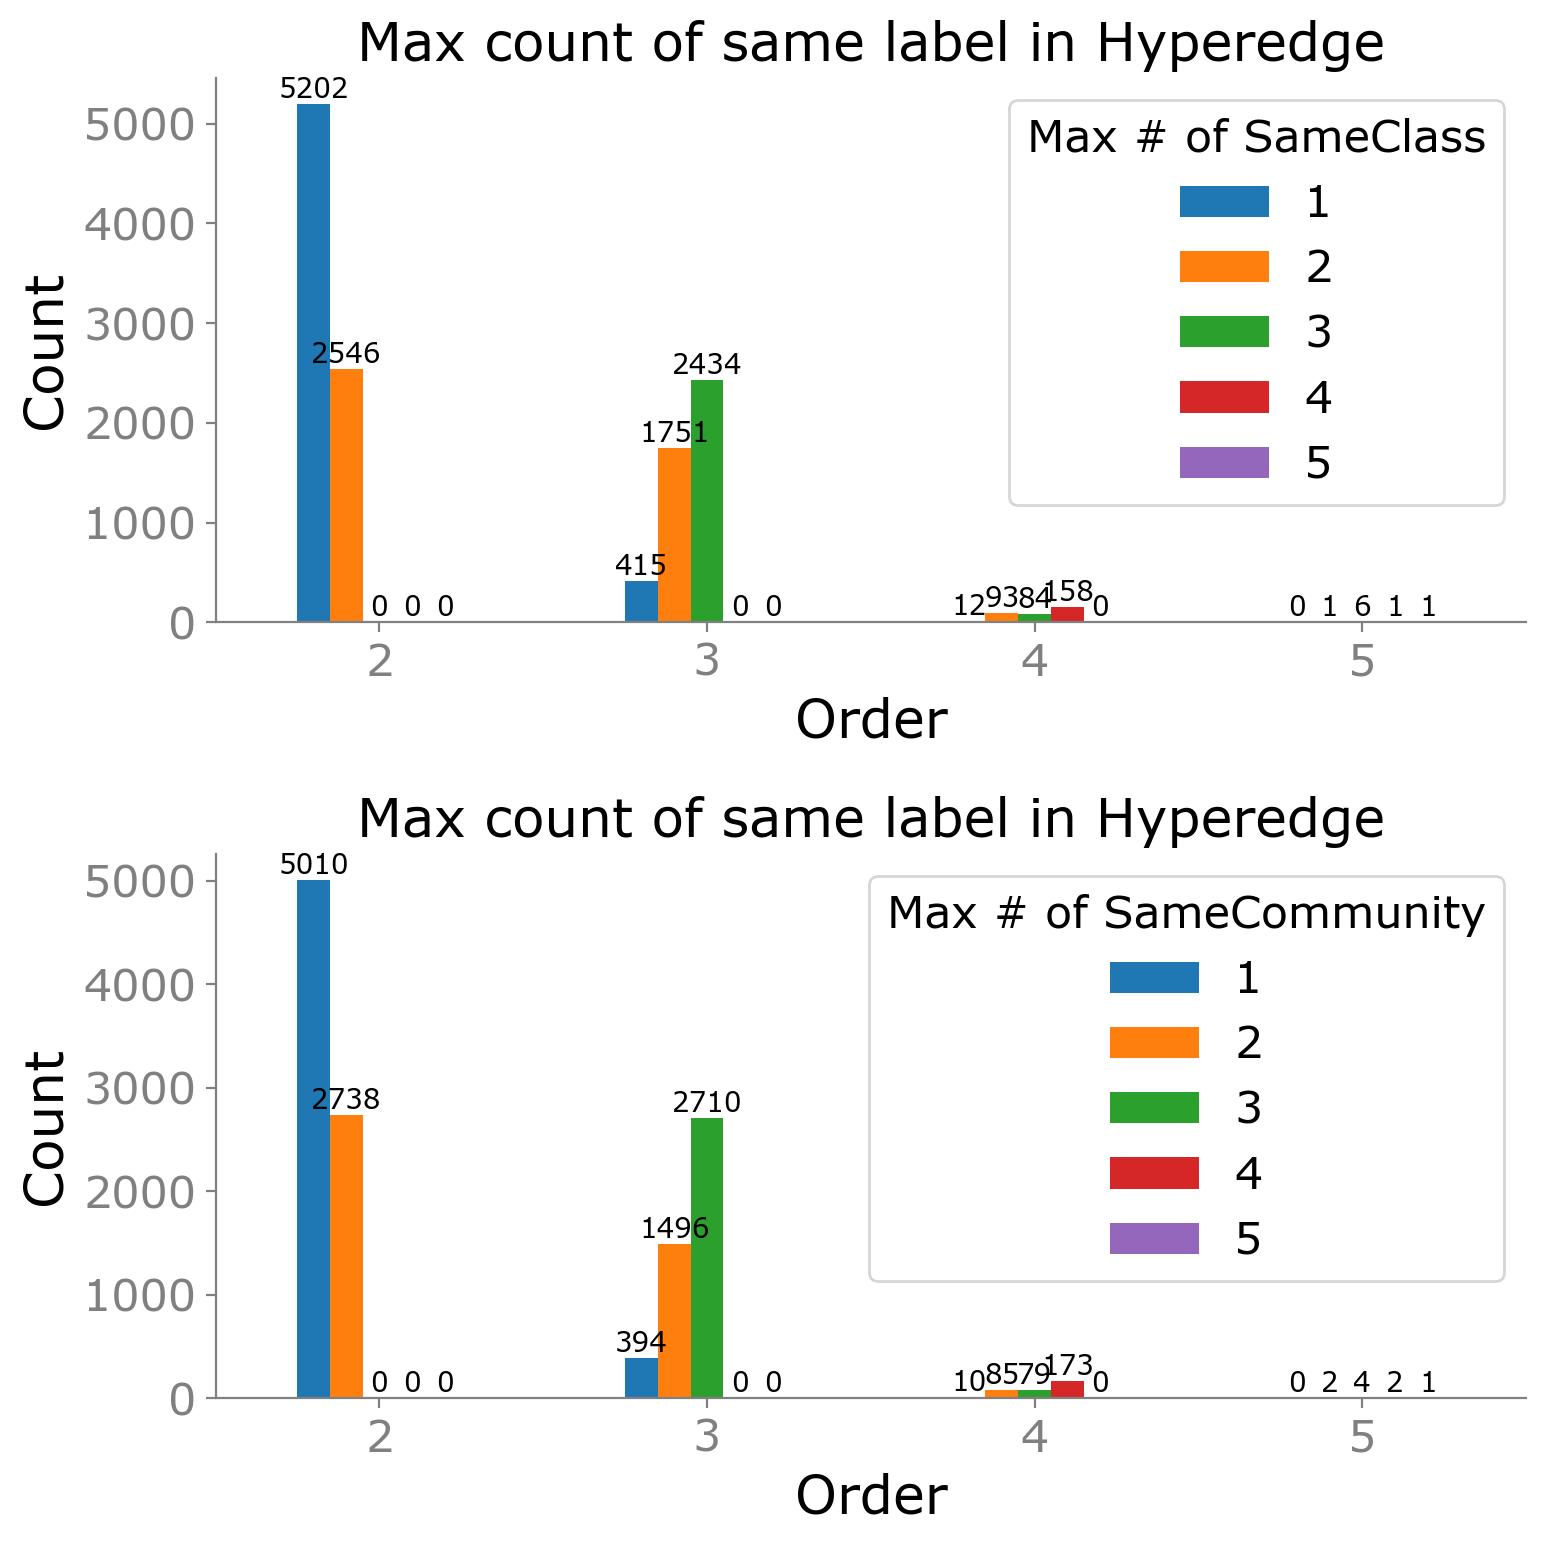

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

df = getGroupBarResultDF(DisHedgeByMeta)
df.plot.bar(ax=axes[0], rot=0)
# 设置图表标题和标签
axes[0].set_title('Max count of same label in Hyperedge')
axes[0].set_xlabel('Order')
axes[0].set_ylabel('Count')
axes[0].legend(title='Max # of SameClass')
addTextOnBar(axes[0])

df = getGroupBarResultDF(DisHedgeByBH)
df.plot.bar(ax=axes[1], rot=0)
# 设置图表标题和标签
axes[1].set_title('Max count of same label in Hyperedge')
axes[1].set_xlabel('Order')
axes[1].set_ylabel('Count')
axes[1].legend(title='Max # of SameCommunity')
addTextOnBar(axes[1])

plt.tight_layout()

# Connect Stength for diff order
Node community incidence matrix : $\Psi\in\left\{0,1\right\}^{n\times q}$.

Node hyperedge incidence matrix : $H\in\left\{0,1\right\}^{n\times m}$.

Communtiy hyperedge matrix: $\Psi^TH$ dimension $q\times m$, the number of nodes of hyperedge in community.

$\mathrm{nonzero}(\Psi^TH)$, at least 1 nodes of hyperedges exist in community.

$\mathrm{nonzero}(\Psi^TH)\mathrm{nonzero}(H^T\Psi)$ , $q\times q$: how many hyperedges related with two communities or 1 communities. 

In [18]:
def connect_strength_community(H, partition_vec, num_group, consider_k=None):
    num_community = num_group
    num_nodes = np.size(partition_vec)
    Node_Community_Incidence = np.zeros((num_nodes, num_community))
    for i in range(num_nodes):
        ci = partition_vec[i]
        Node_Community_Incidence[i, ci] = 1
    if consider_k is not None:
        edge_order = H.sum(axis=0).flatten()
        edge_index = np.where(edge_order == consider_k)[0]
        H = H[:, edge_index]
    # Connect_Strength = np.transpose(Node_Community_Incidence) @ H
    # Connect_Strength = Connect_Strength @ H.transpose()
    # Connect_Strength = Connect_Strength @ Node_Community_Incidence
    
    Community_Paper_Incidence = np.transpose(Node_Community_Incidence) @ H  # (c, j) the number of nodes of hyperedge j in community c
    Connect_Strength = ((Community_Paper_Incidence) !=0).astype(int)
    Connect_Strength = Connect_Strength @ ((np.transpose(Community_Paper_Incidence)!=0).astype(int))  # (c, c') the number of hyperedges related with community c and c' for c!=c'
    # author_counts = H.sum(axis=0)  # the number of nodes for hyperedge
    # for ci in range(num_community):
    #     # print(np.sum(((Community_Paper_Incidence[ci, :] - author_counts)==0).astype(int)))
    #     Connect_Strength[ci, ci] = np.sum(((Community_Paper_Incidence[ci, :] - author_counts) == 0).astype(int))  # the number of papers with all authors in community ci
    print(type(Connect_Strength), np.shape(Connect_Strength))
    """
    Connect_Strength is a (num_community, num_community) matrix, 
    where Connect_Strength[c, c'] is the number of hedges with some nodes in community c and some nodes in c' for c!=c',
    and Connect_Strength[c, c] is the number of hedges with all nodes in community c.
    """
    # print(Connect_Strength)  
    return Connect_Strength

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].
{2: 5498, 3: 2091, 4: 222, 5: 7}
<class 'numpy.ndarray'> (9, 9)
<class 'numpy.ndarray'> (9, 9)


Text(0.5, 1.0, 'highschool Order 4')

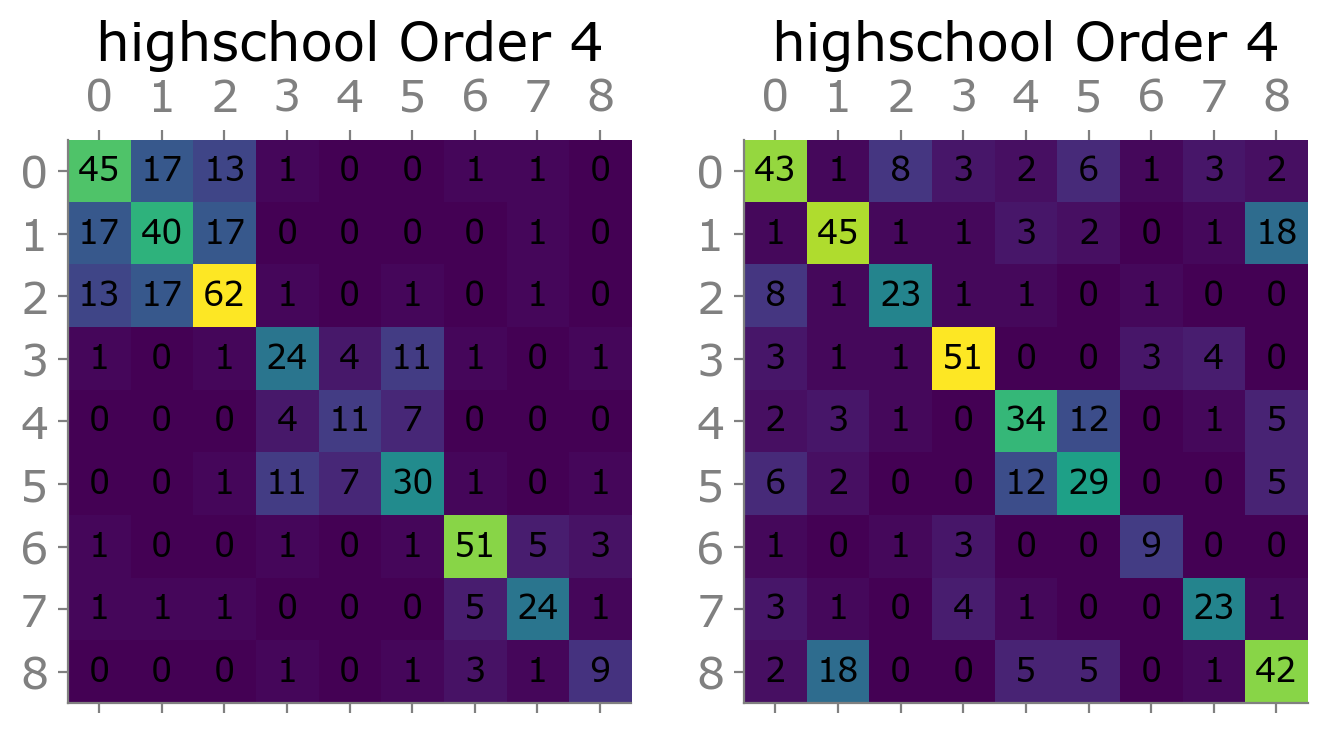

In [32]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
givenNumGroup = 9
only_assortative = True
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    BHpartition = pickle.load(fr)

meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = [np.where(np.unique(meta)==m)[0][0] for m in meta]
meta = np.array(meta)
# print(meta)

consider_k = 4
Connect_Strength = connect_strength_community(H=ehg.H, partition_vec=meta, num_group=givenNumGroup, consider_k=consider_k)
# df = pd.DataFrame(Connect_Strength, columns=list(range(num_groups)), index=list(range(num_groups)))
# df.to_excel(f"./result/cnPhy_modularity_connect_strength_matrix.xlsx")
fig = plt.figure(figsize=(8, 4))
widths = [4, 4]
heights = [4]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
im = ax.matshow(Connect_Strength)
for i in range(givenNumGroup):
    for j in range(givenNumGroup):
        c = Connect_Strength[i,j]
        plt.gca().text(j, i, str(int(c)), va='center', ha='center', fontsize=12)
plt.title(f"{name} Order {consider_k}")

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
Connect_Strength = connect_strength_community(H=ehg.H, partition_vec=BHpartition, num_group=givenNumGroup, consider_k=consider_k)
im = ax.matshow(Connect_Strength)
for i in range(givenNumGroup):
    for j in range(givenNumGroup):
        c = Connect_Strength[i,j]
        plt.gca().text(j, i, str(int(c)), va='center', ha='center', fontsize=12)
plt.title(f"{name} Order {consider_k}")


Construct primary hypergraph with 242 nodes, 12704 hyperedges and all possible k is [2, 3, 4, 5].
{2: 7748, 3: 4600, 4: 347, 5: 9}
[5, 5, 5, 5, 5, 7, 7, 7, 1, 1, 7, 7, 4, 4, 4, 4, 5, 0, 0, 7, 7, 7, 6, 6, 0, 0, 8, 8, 2, 2, 0, 8, 8, 8, 8, 8, 8, 6, 2, 2, 0, 0, 0, 0, 0, 0, 0, 8, 8, 8, 8, 2, 2, 2, 2, 4, 0, 8, 8, 8, 8, 8, 7, 8, 0, 0, 4, 4, 0, 0, 5, 4, 2, 2, 8, 7, 2, 9, 9, 5, 10, 9, 9, 9, 9, 2, 7, 9, 9, 9, 9, 9, 10, 7, 7, 7, 9, 9, 9, 9, 1, 1, 9, 9, 10, 2, 2, 2, 2, 7, 2, 2, 2, 7, 7, 7, 7, 4, 4, 1, 1, 7, 6, 1, 1, 6, 6, 6, 1, 1, 10, 2, 1, 1, 1, 1, 1, 6, 6, 1, 1, 1, 6, 6, 1, 1, 1, 4, 6, 6, 6, 7, 9, 2, 2, 6, 1, 1, 9, 4, 9, 6, 4, 5, 5, 4, 4, 9, 10, 4, 9, 9, 4, 4, 4, 4, 5, 8, 4, 6, 10, 0, 0, 5, 0, 5, 5, 5, 10, 5, 5, 4, 5, 5, 1, 6, 6, 5, 4, 5, 10, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 10, 3, 3, 7, 3, 6, 6, 0, 10, 0, 8, 8, 7, 9, 3, 5, 0, 2]
<class 'numpy.ndarray'> (10, 10)


Text(0.5, 1.0, 'primary Order 3')

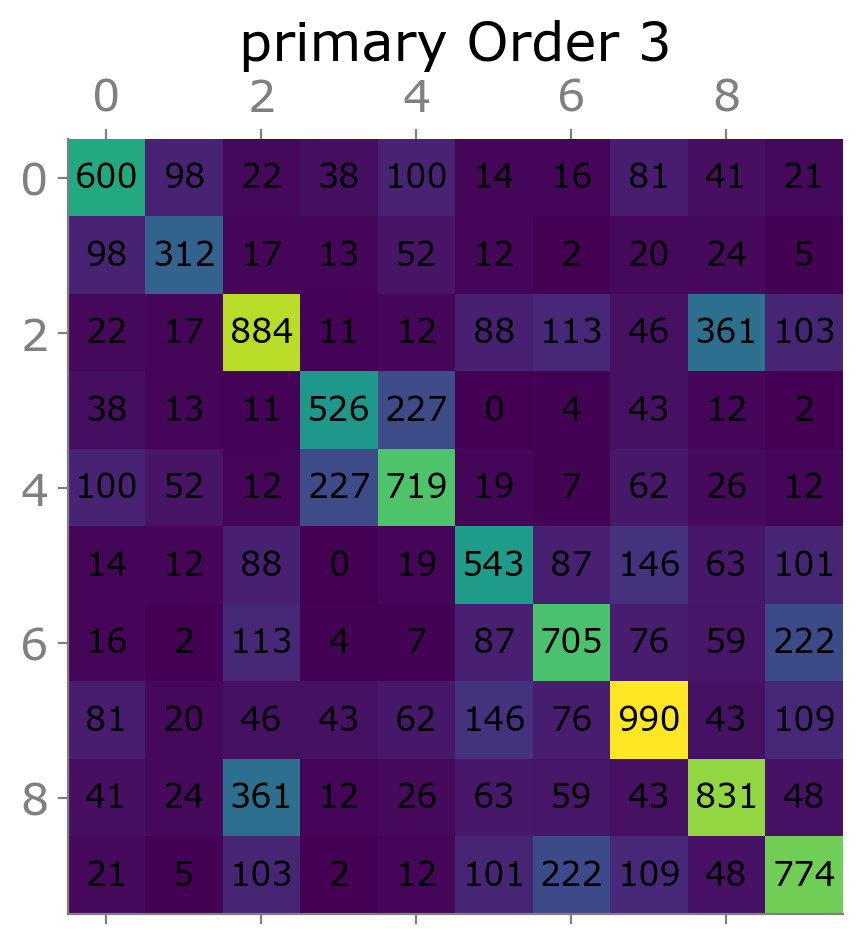

In [27]:
name = "primary"
ehg = EmpiricalHyperGraph(name)
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
# partition detected by BH
givenNumGroup = 10
only_assortative = False
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
partition = None
with open(partition_path, 'rb') as fr:
    partition = pickle.load(fr)

meta = []
with open('./net_data/contact-primary-school/primary_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        meta.append(_data['meta'][i])
meta = [np.where(np.unique(meta)==m)[0][0] for m in meta]
print(meta)
meta = np.array(meta)

consider_k = 3
Connect_Strength = connect_strength_community(H=ehg.H, partition_vec=partition, num_group=givenNumGroup, consider_k=consider_k)
# df = pd.DataFrame(Connect_Strength, columns=list(range(num_groups)), index=list(range(num_groups)))
# df.to_excel(f"./result/cnPhy_modularity_connect_strength_matrix.xlsx")
im = plt.matshow(Connect_Strength)
for i in range(givenNumGroup):
    for j in range(givenNumGroup):
        c = Connect_Strength[i,j]
        plt.gca().text(j, i, str(int(c)), va='center', ha='center', fontsize=12)
plt.title(f"{name} Order {consider_k}")